In [1]:
import json
import torch
import numpy as np
import random
import os
import pandas as pd
import sys
import random
import math
import argparse
import datetime
import wandb
import pickle
from pathlib import Path

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import plotly.graph_objects as go

from typing import List, Optional
import fire

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from typing import List

from fairscale.nn.model_parallel.initialize import (
    get_model_parallel_rank,
    initialize_model_parallel,
    model_parallel_is_initialized,
)
from fairscale.nn.model_parallel.layers import (
    ColumnParallelLinear,
    RowParallelLinear,
    VocabParallelEmbedding,
)

import argparse, yaml, json
import datetime
from pathlib import Path

curr_date = datetime.datetime.now().strftime("%Y%m%d")

def str2bool(v):
    if isinstance(v, bool):
        return v
    if v.lower() in ("yes", "true", "t", "1"):
        return True
    elif v.lower() in ("no", "false", "f", "0"):
        return False
    else:
        raise argparse.ArgumentTypeError("Boolean value expected.")


In [2]:
# --- Pre-parser for config location ---
pre_parser = argparse.ArgumentParser(description="Config Loader", add_help=False)
pre_parser.add_argument("--config",      type=str, default="~/Neurosymbolic-LLM/Programs/fine_tune_decoders_default_config.yaml", help="Path to YAML configuration file")
pre_parser.add_argument("--master_port", type=int, default=29500, help="Port for distributed init (must be unique per job)")
pre_parser.add_argument("--run_name",    type=str, default=curr_date, help="Name of run (used for wandb and to save model files)")

config_args, remaining_argv = pre_parser.parse_known_args()
with open(str(Path(config_args.config).expanduser()), "r") as f:
    config_defaults = yaml.safe_load(f)

master_port = str(config_args.master_port)
run_name    = config_args.run_name

# --- Full parser with YAML defaults ---
parser = argparse.ArgumentParser(description="Fine tune decoders")

# === Run general information ===
parser.add_argument("--curr_dir",       type=str,  required=False, help="Directory of Program",            default="~/Neurosymbolic-LLM/Programs")
parser.add_argument("--git_dir",        type=str,  required=False, help="Directory of Main Github",        default="~/Neurosymbolic-LLM")
parser.add_argument("--ckpt_dir",       type=str,  required=False, help="Model Checkpoint Directory",      default="~/.llama/checkpoints/Llama3.1-8B-Instruct")
parser.add_argument("--tokenizer_path", type=str,  required=False, help="Tokenizer Checkpoint Directory",  default="~/.llama/checkpoints/Llama3.1-8B-Instruct/tokenizer.model")
parser.add_argument("--log_wandb",      type=int,  required=False, help="Whether to log outputs to wandb", default=1,)

# === Model + generation ===
parser.add_argument("--max_seq_len",         type=int, default=config_defaults.get("max_seq_len"),         required=False, help="Max sequence length")
parser.add_argument("--max_batch_size",      type=int, default=config_defaults.get("max_batch_size"),      required=False, help="Max batch size")
parser.add_argument("--model_parallel_size", type=int, default=config_defaults.get("model_parallel_size"), required=False, help="Model parallelism")

# === Symbolic engine ===
parser.add_argument("--max_digits",                     type=int,   default=config_defaults.get("max_digits"),       required=False, help="Max digits (affects number range)")
parser.add_argument("--VSA_dim",                        type=int,   default=config_defaults.get("VSA_dim"),          required=False, help="Vector Symbolic Architecture dimension")
parser.add_argument("--possible_problems",  nargs="+",  type=str,  default=config_defaults.get("possible_problems"), required=False, help="Supported symbolic problems")

# === Paths ===
parser.add_argument("--encoder_path", type=str, default=config_defaults.get("encoder_path"), required=False, help="Path to encoder model")
parser.add_argument("--decoder_path", type=str, default=config_defaults.get("decoder_path"), required=False, help="Path to decoder model")
parser.add_argument("--save_model",   type=str2bool, default=config_defaults.get("save_model"),   required=False, help="Whether to save model")

# === Training logic ===
parser.add_argument("--problem_type",              nargs="+",  type=str, default=config_defaults.get("problem_type"), required=False)
parser.add_argument("--complexity",                type=int,   default=config_defaults.get("complexity"), required=False)
parser.add_argument("--temperature",               type=float, default=config_defaults.get("temperature"), required=False)

parser.add_argument("--train_model",               type=str2bool,  default=config_defaults.get("train_model"), required=False)
parser.add_argument("--validate_model",            type=str2bool,  default=config_defaults.get("validate_model"), required=False)
parser.add_argument("--test_model",                type=str2bool,  default=config_defaults.get("test_model"),  required=False)
parser.add_argument("--lora_baseline",             type=str2bool,  default=config_defaults.get("lora_baseline"), required=False)
parser.add_argument("--starting_skip_strength",    type=float, default=config_defaults.get("starting_skip_strength"), required=False)
parser.add_argument("--problem_score_threshold",   type=float, default=config_defaults.get("problem_score_threshold"), required=False)
parser.add_argument("--normalize_VSA_before_dot",  type=str2bool,  default=config_defaults.get("normalize_VSA_before_dot"), required=False)
parser.add_argument("--initialize_decoders",       type=str2bool,  default=config_defaults.get("initialize_decoders"), required=False)
parser.add_argument("--normalize_vector",          type=str2bool,  default=config_defaults.get("normalize_vector"), required=False)
parser.add_argument("--rms_layer",                 type=str2bool,  default=config_defaults.get("rms_layer"), required=False)
parser.add_argument("--single_number_generation",  type=str2bool,  default=config_defaults.get("single_number_generation"), required=False)
parser.add_argument("--use_specific_identities",   type=str2bool,  default=config_defaults.get("use_specific_identities"), required=False)
parser.add_argument("--trainable_skip",            type=str2bool,  default=config_defaults.get("trainable_skip"), required=False)
parser.add_argument("--symbolic_encoding_layer",   type=int,   default=config_defaults.get("symbolic_encoding_layer"), required=False)
parser.add_argument("--symbolic_decoding_layers", nargs="+", type=int, default=config_defaults.get("symbolic_decoding_layers"), required=False)

# === Optimization ===
parser.add_argument("--num_epochs",                      type=int,        default=config_defaults.get("num_epochs"), required=False)
parser.add_argument("--num_steps",                       type=int,        default=config_defaults.get("num_steps"), required=False)
parser.add_argument("--n_samples",                       type=int,        default=config_defaults.get("n_samples"), required=False)
parser.add_argument("--inference_to_backprop_ratio",     type=int,        default=config_defaults.get("inference_to_backprop_ratio"), required=False)
parser.add_argument("--learning_rate",                   type=float,      default=config_defaults.get("learning_rate"), required=False)
parser.add_argument("--learning_rate_reduction_factors", type=json.loads, default=json.dumps(config_defaults.get("learning_rate_reduction_factors")), required=False)

# === Logging + verbosity ===
parser.add_argument("--steps_to_print",      type=int, default=config_defaults.get("steps_to_print"), required=False)
parser.add_argument("--print_all_pts_freq",  type=int, default=config_defaults.get("print_all_pts_freq"), required=False)
parser.add_argument("--verbose",             type=int, default=config_defaults.get("verbose"), required=False)

# === Validation ===
parser.add_argument("--val_num_steps",                   type=int,        default=config_defaults.get("val_num_steps"), required=False)
parser.add_argument("--val_inference_to_backprop_ratio", type=int,        default=config_defaults.get("val_inference_to_backprop_ratio"), required=False)
parser.add_argument("--val_n_samples",                   type=int,        default=config_defaults.get("val_n_samples"), required=False)
parser.add_argument("--val_temperature",                 type=float,      default=config_defaults.get("val_temperature"), required=False)
parser.add_argument("--val_steps_to_print",              type=int,        default=config_defaults.get("val_steps_to_print"), required=False)
parser.add_argument("--val_verbose",                     type=int,        default=config_defaults.get("val_verbose"), required=False)

# === Testing ===
parser.add_argument("--testing_problems",         nargs="+", type=str,        default=config_defaults.get("testing_problems"), required=False)
parser.add_argument("--testing_num_steps",                   type=int,        default=config_defaults.get("testing_num_steps"), required=False)
parser.add_argument("--testing_inference_to_backprop_ratio", type=int,        default=config_defaults.get("testing_inference_to_backprop_ratio"), required=False)
parser.add_argument("--testing_n_samples",                   type=int,        default=config_defaults.get("testing_n_samples"), required=False)
parser.add_argument("--testing_temperature",                 type=float,      default=config_defaults.get("testing_temperature"), required=False)
parser.add_argument("--testing_steps_to_print",              type=int,        default=config_defaults.get("testing_steps_to_print"), required=False)
parser.add_argument("--testing_verbose",                     type=int,        default=config_defaults.get("testing_verbose"), required=False)
parser.add_argument("--record_score_per_problem",            type=int,        default=config_defaults.get("record_score_per_problem"), required=False)

parser.add_argument("--test_baseline",               type=int,      default=config_defaults.get("test_baseline"), required=False)
parser.add_argument("--cot",                         type=str2bool, default=config_defaults.get("cot"), required=False)
parser.add_argument("--test_on_unrelated_questions", type=str2bool, default=config_defaults.get("test_on_unrelated_questions"), required=False)
parser.add_argument("--test_with_non_numerical_rep", type=str2bool, default=config_defaults.get("test_with_non_numerical_rep"), required=False)

# === Encoder-specific ===
parser.add_argument("--encoder_input_tokens",        type=str,      default=config_defaults.get("encoder_input_tokens"), required=False)
parser.add_argument("--calculate_end_index",         type=str2bool, default=config_defaults.get("calculate_end_index"), required=False)
parser.add_argument("--multi_token_intervention",    type=str2bool, default=config_defaults.get("multi_token_intervention"), required=False)
parser.add_argument("--static_encoding",             type=str2bool, default=config_defaults.get("static_encoding"), required=False)
parser.add_argument("--calculate_encoding_accuracy", type=str2bool, default=config_defaults.get("calculate_encoding_accuracy"), required=False)
parser.add_argument("--encode_counter",              type=str2bool, default=config_defaults.get("encode_counter"), required=False)

parser.add_argument("--limit_solution_digits",       type=str2bool, default=config_defaults.get("limit_solution_digits"),    required=False)
parser.add_argument("--save_responses",              type=str2bool, default=config_defaults.get("save_responses"),           required=False)
parser.add_argument("--simulate_perfect_encoder",    type=str2bool, default=config_defaults.get("simulate_perfect_encoder"), required=False)
parser.add_argument("--modify_question_format",      type=str2bool, default=config_defaults.get("modify_question_format"),   required=False)

parser.add_argument("--training_data_df_path", type=str, default=config_defaults.get("training_data_df_path"), help="Path to pre-generated training dataset (leave as '' to run based on randomly sampled data)")
parser.add_argument("--val_data_df_path", type=str, default=config_defaults.get("val_data_df_path"), help="Path to pre-generated validation dataset (leave as '' to run based on randomly sampled data)")
parser.add_argument("--testing_data_df_path", type=str, default=config_defaults.get("testing_data_df_path"), help="Path to pre-generated testing dataset (leave as '' to run based on randomly sampled data)")


_StoreAction(option_strings=['--testing_data_df_path'], dest='testing_data_df_path', nargs=None, const=None, default='', type=<class 'str'>, choices=None, help="Path to pre-generated testing dataset (leave as '' to run based on randomly sampled data)", metavar=None)

In [3]:
args = parser.parse_args([])



In [4]:
args.run_name = "linear_encoder_3_digit_data_pre_generated_dataset_x_gt_y_notebook"
args.encoder_input_tokens = 1
args.symbolic_encoding_layer = 17
args.symbolic_decoding_layer = [17]
args.initialize_decoders = True
args.encoder_path = "~/Neurosymbolic-LLM/Programs/models/encoders_linear_encoder_3_digit_data_pre_generated_dataset_x_gt_y.pth"
args.decoder_path = "~/Neurosymbolic-LLM/Programs/models/decoders_linear_encoder_3_digit_data_pre_generated_dataset_x_gt_y.pth"
args.training_data_df_path = "~/Symbolic-Math-Dataset/datasets/symbolic_math_dataset_2_complexity_x_gt_y_20000_training_samples.csv"
args.val_data_df_path = "~/Symbolic-Math-Dataset/datasets/symbolic_math_dataset_2_complexity_x_gt_y_200_validation_samples.csv"
args.testing_data_df_path = "~/Symbolic-Math-Dataset/datasets/symbolic_math_dataset_2_complexity_x_gt_y_2000_testing_samples.csv"

In [5]:
args.curr_dir              = str(Path(args.curr_dir).expanduser())
args.git_dir               = str(Path(args.git_dir ).expanduser())
args.ckpt_dir              = str(Path(args.ckpt_dir).expanduser())
args.tokenizer_path        = str(Path(args.tokenizer_path).expanduser())
args.training_data_df_path = str(Path(args.training_data_df_path).expanduser()) if args.training_data_df_path else ''
args.val_data_df_path      = str(Path(args.val_data_df_path).expanduser()) if args.val_data_df_path else ''
args.testing_data_df_path  = str(Path(args.testing_data_df_path).expanduser()) if args.testing_data_df_path else ''

args.log_wandb         = bool(args.log_wandb)
args.n_samples         = min(args.n_samples,         args.max_batch_size)
args.testing_n_samples = min(args.testing_n_samples, args.max_batch_size)

curr_dir = args.curr_dir
git_dir  = args.git_dir
ckpt_dir = args.ckpt_dir
tokenizer_path = args.tokenizer_path
log_wandb = args.log_wandb

max_seq_len         = args.max_seq_len
max_batch_size      = args.max_batch_size
model_parallel_size = args.model_parallel_size

max_digits          = args.max_digits
VSA_dim             = args.VSA_dim
possible_problems   = args.possible_problems


sys.path.insert(0, git_dir)

from llama.model import ModelArgs, Transformer, RMSNorm
from llama.generation import sample_top_p
from llama.encoder_decoder_networks import Encoder, Decoder, Encoder_Deep, Decoder_Deep
from llama.vsa_engine import *
from llama.utilities import *

from llama import Dialog, Llama

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.get_device_name(torch.cuda.current_device()))

os.environ['RANK'] = "0"
os.environ['WORLD_SIZE'] = "1"
os.environ['MASTER_ADDR'] = "127.0.0.2"
os.environ['MASTER_PORT'] = '25099'
os.environ['LOCAL_RANK']  = "0"
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ['TORCH_USE_CUDA_DSA'] = '1'

generator = Llama.build(
    ckpt_dir=ckpt_dir,
    tokenizer_path=tokenizer_path,
    max_seq_len=max_seq_len,
    max_batch_size=max_batch_size,
)


NVIDIA RTX 6000 Ada Generation
> initializing model parallel with size 1
> initializing ddp with size 1
> initializing pipeline with size 1
Loaded in 19.00 seconds


In [6]:
possible_problems_str = "_".join(possible_problems)

if os.path.exists(f"{curr_dir}/VSA_library/symbolic_engine_VSA_dim_{VSA_dim}_max_digits_{max_digits}_problem_types_{possible_problems_str}.pt"):
    SE = torch.load(f"{curr_dir}/VSA_library/symbolic_engine_VSA_dim_{VSA_dim}"
                    f"_max_digits_{max_digits}_problem_types_{possible_problems_str}.pt", weights_only=False)
else:
    print("Warning: Existing Symbolic Engine object not found, creating new Symbolic Engine...")
    SE = SymbolicEngine(VSA_dim=VSA_dim, max_digits=max_digits, possible_problems=possible_problems, 
                        curr_dir=curr_dir)
    torch.save(SE, f"{curr_dir}/VSA_library/symbolic_engine_VSA_dim_{VSA_dim}_max_digits_{max_digits}_problem_types_{possible_problems_str}.pt")


generator.model.SE = torch.load(f"{curr_dir}/VSA_library/symbolic_engine_VSA_dim_{VSA_dim}"
                                f"_max_digits_{max_digits}_problem_types_{possible_problems_str}.pt", weights_only=False)


def get_dialog_indices(generator, dialog, calculate_end_index=False):
    start_indices = []
    end_indices   = []
    for i in range(len(dialog)):
        # Find the final occurance of user chat (which is the question being asked to the LLM)
        start_index = len(generator.parse_chat(dialog)[i]) - generator.parse_chat(dialog)[i][::-1].index(882) + 2
        # The final token position to save
        if not calculate_end_index:
            end_index   = -1 # If end_index is -1, use all tokens up till the end, otherwise calculate based on eot token
        else:
            end_index   = len(generator.parse_chat(dialog)[i]) - generator.parse_chat(dialog)[i][::-1].index(128009) - 1
        start_indices += [start_index]
        end_indices   += [end_index]
        
    return start_indices, end_indices

def training_step(n_samples, generator, temperature=0, problem_type="addition", df_dialogs=None, inference_to_backprop_ratio=1, 
                  optimizer=None, criterion=None, complexity=2, losses_per_pt=None, scores_per_pt=None, verbose=False):

    all_logits = []
    all_corr  = []

    total_score = 0
    outputs = []
    all_correct_responses = []
    all_dialogs = []
    pts     = []

    if type(df_dialogs) == type(None):
        generate_random_dialog = True
    else:
        generate_random_dialog = False

        # If the length of the current batch is not equal to the number of samples the LLM will consume times the 
        #  inference_to_backprop_ratio, adjust the inference_to_backprop_ratio accordingly
        if len(df_dialogs) // n_samples != inference_to_backprop_ratio:
            inference_to_backprop_ratio = len(df_dialogs) // n_samples

        batch_question, batch_problem_type = df_dialogs["question"], df_dialogs["problem_type"]
        batch_x, batch_y, batch_solution   = df_dialogs["x"], df_dialogs["y"], df_dialogs["solution"]

        # batch_dialog_data is a list of lists, with length equal to the length of df_dialogs. Each list contains 4 items. The first is 
        #  the dialogs object, which is a list of Dialog objects, the length of which is equal to n_samples. The second is the x values, which is 
        #  an array of integers, the third is the y values (also array of integers), and the final is the problem type, a string
        batch_dialog_data = [generate_dialog(complexity=complexity, samples=1,
                                             problem_type=pt) for pt in batch_problem_type]

        for d in range(n_samples):
            # First index is grabbing the batch item, second index is grabbing the dialog (instead of the x, y , pt),
            #  third index is grabbing the batch item within dialogs (which is always of length 1 due to samples=1 above), and last
            #  index is grabbing the last dialog sequence, since we only want to change that while leaving the example dialogs the same
            batch_dialog_data[d][0][0][-1]['content'] = batch_question.values[d]
            batch_dialog_data[d][1][0], batch_dialog_data[d][2][0] = batch_x.values[d], batch_y.values[d]


        # batch_dialog_data should be [dialog, x, y, pt], where each element is n_samples long. batch_dialog_data previously was of length n_samples, where each
        #  item in the sequence was [dialog, x, y, pt]. The below code puts it into the correct format
        batch_dialog_data = [[d[0][0] for d in batch_dialog_data],
                             np.array([d[1][0] for d in batch_dialog_data]),
                             np.array([d[2][0] for d in batch_dialog_data]),
                             batch_problem_type.values]
        
    for n in range(inference_to_backprop_ratio):
        if verbose:
            print("On sub-step iteration:", n+1)
        response_data = {}

        total_loss = 0

        if generate_random_dialog:
            dialogs, x, y, curr_problem_type = generate_dialog(complexity=complexity, samples=n_samples, problem_type=problem_type, 
                                                               limit_solution_digits=generator.model.limit_solution_digits, modify_question_format=generator.model.modify_question_format)
        else:
            micro_batch_dialog_data = [batch_dialog_data[0][(n) * n_samples : (n + 1) * n_samples], batch_dialog_data[1][(n) * n_samples : (n + 1) * n_samples], 
                                       batch_dialog_data[2][(n) * n_samples : (n + 1) * n_samples], batch_dialog_data[3][(n) * n_samples : (n + 1) * n_samples]]
            dialogs, x, y, curr_problem_type = micro_batch_dialog_data[0], micro_batch_dialog_data[1], micro_batch_dialog_data[2], micro_batch_dialog_data[3]
            curr_problem_type = curr_problem_type[0] # TODO: Fix this hack (by getting the forward pass to accept multiple different problem types). Current workaround is setting n_samples to 1
            #print("curr_dialogs:", dialogs, x, y, curr_problem_type)

        all_dialogs += [dialogs]
        if generator.model.encoder_input_tokens == "all":
            start_indices, end_indices    = get_dialog_indices(generator, dialogs, calculate_end_index=generator.model.calculate_end_index)
            generator.model.curr_start_indices = start_indices
            generator.model.curr_end_indices   = end_indices
            generator.model.dialogs            = dialogs

        if generator.model.calculate_encoding_accuracy:
            generator.model.curr_x  = x
            generator.model.curr_y  = y
            generator.model.curr_pt = curr_problem_type

        pts += [curr_problem_type]
        if curr_problem_type=="addition":
            correct_responses = [x[i] + y[i] for i in range(len(x))]
        elif curr_problem_type=="multiplication":
            if generator.model.limit_solution_digits:
                correct_responses = [(x[i] * y[i]) % 10**(complexity+1) for i in range(len(x))]
            else:
                correct_responses = [(x[i] * y[i]) for i in range(len(x))]
        elif curr_problem_type=="division":
            correct_responses = [int(x[i] // y[i]) for i in range(len(x))]
        elif curr_problem_type=="modulo":
            correct_responses = [x[i] % y[i] for i in range(len(x))]
        elif curr_problem_type=="gcd":
            correct_responses = [np.gcd(x[i], y[i]) for i in range(len(x))]
        elif curr_problem_type=="lcm":
            if generator.model.limit_solution_digits:
                correct_responses = [np.lcm(x[i], y[i]) % 10**(complexity+1) for i in range(len(x))]
            else:
                correct_responses = [np.lcm(x[i], y[i]) for i in range(len(x))]
        elif curr_problem_type=="square_mod":
            correct_responses = [x[i]**2 % y[i] for i in range(len(x))]
        elif curr_problem_type=="bitwise_and":
            correct_responses = [x[i] & y[i] for i in range(len(x))]
        elif curr_problem_type=="bitwise_xor":
            correct_responses = [x[i] ^ y[i] for i in range(len(x))]
        elif curr_problem_type=="bitwise_or":
            correct_responses = [x[i] | y[i] for i in range(len(x))]
        elif curr_problem_type=="bitwise_nand":
            correct_responses = [~(x[i] & y[i]) for i in range(len(x))]
        elif curr_problem_type=="bitwise_nxor":
            correct_responses = [~(x[i] ^ y[i]) for i in range(len(x))]
        elif curr_problem_type=="bitwise_nor":
            correct_responses = [~(x[i] | y[i]) for i in range(len(x))]
        else:
            print("Unrecognized problem type:", curr_problem_type)
        

        all_correct_responses += correct_responses

        # Shape of list_of_probs and list_of_logits is (sequence_output_length, batch_size, num_tokens)
        h_stack, list_of_probs, list_of_logits, out_tokens = episode(dialogs=dialogs, generator=generator, temperature=temperature,
                                                                     inference_mode=generator.model.forward_symbolic_funnel, 
                                                                     max_decoding_length=complexity+5, verbose=verbose)

        #print(list_of_logits.shape, list_of_probs.shape)

        all_logits = all_logits + [list_of_logits]
        all_corr   = all_corr   + [torch.tensor(correct_responses)]

        for i in range(len(out_tokens)): # Iterate over n_samples
            try:
                output = int(generator.tokenizer.decode(out_tokens[i]))
                score  = int(output == correct_responses[i])
            except Exception as e:
                if verbose:
                    print("!! Can't convert to int !!:", e)
                output = generator.tokenizer.decode(out_tokens[i])
                score = 0
            total_score += score
            if type(problem_type) == list:
                scores_per_pt[curr_problem_type] += [score]
            outputs += [output]
            if verbose == 2 or (verbose and i == 0):
                print("Actual values:                        ",
                      "first number:", x[i], "second number:", y[i], 
                      curr_problem_type + ":", correct_responses[i],
                      "LLM response:", output, "score:", score)


    max_len = max(t.size(0) for t in all_logits)
    padded_tensors = []
    for t in all_logits:
        T, B, V = t.shape
        pad_amount = max_len - T
        t_padded = F.pad(t, (0, 0, 0, 0, 0, pad_amount), value=0)
        padded_tensors.append(t_padded)

    all_logits = torch.cat(padded_tensors, dim=1)
    all_corr   = torch.concat(all_corr)

    optimizer.zero_grad()

    stop_token = generator.tokenizer.special_tokens["<|eot_id|>"]

    loss = 0
    losses = []
    for batch in range(len(all_corr)):
        correct_tokens = torch.tensor(generator.tokenizer.encode(str(all_corr[batch].item()), bos=False, eos=False))
        correct_tokens = torch.cat([correct_tokens, torch.tensor([stop_token])])
        correct_sequence_length  = len(correct_tokens)
        response_sequence_length = all_logits[:,batch,:].shape[0]
        sequence_length = min(correct_sequence_length, response_sequence_length)
        batch_loss = criterion(all_logits[:sequence_length,batch,:], correct_tokens[:sequence_length])
        loss += batch_loss
        losses += [batch_loss.detach().cpu().item()]
        losses_per_pt[pts[batch//n_samples]] += [batch_loss.detach().cpu().float()]
        if log_wandb:
            wandb.log({
                f"step_{pts[batch//n_samples]}": len(losses_per_pt[pts[batch//n_samples]])-1,
                f"loss_{ pts[batch//n_samples]}": losses_per_pt[pts[batch//n_samples]][-1],
                f"score_{pts[batch//n_samples]}": scores_per_pt[pts[batch//n_samples]][-1],
            })

    loss = loss / len(all_corr)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()

    total_score = total_score / len(all_corr)

    if verbose:
        tn = 0
        for p in generator.model.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                tn += param_norm.item() ** 2
        total_norm = (tn ** 0.5) / len(dialogs) # normalize by batch size
        print(f"Total gradient norm after clipping: {total_norm}")

    response_data = {
        "Model Guesses": outputs,
        "Correct Answer": all_correct_responses,
        "Losses": losses,
        "All Dialogs": dialogs,
    }


    return total_loss, total_score, response_data

def inference_step(n_samples, generator, temperature=0, problem_type="addition", df_dialogs=None, 
                   inference_to_backprop_ratio=1, criterion=None, cot=False, complexity=2, verbose=False):

    all_logits = []
    all_corr  = []

    total_score = 0
    outputs = []
    pts     = []

    if type(df_dialogs) == type(None):
        generate_random_dialog = True
    else:
        #print("df_dialogs shape:", df_dialogs.shape)
        generate_random_dialog = False

        # If the length of the current batch is not equal to the number of samples the LLM will consume times the 
        #  inference_to_backprop_ratio, adjust the inference_to_backprop_ratio accordingly
        if len(df_dialogs) // n_samples != inference_to_backprop_ratio:
            inference_to_backprop_ratio = len(df_dialogs) // n_samples
        batch_question, batch_problem_type = df_dialogs["question"], df_dialogs["problem_type"]
        batch_x, batch_y, batch_solution   = df_dialogs["x"], df_dialogs["y"], df_dialogs["solution"]

        # batch_dialog_data is a list of lists, with length equal to the length of df_dialogs. Each list contains 4 items. The first is 
        #  the dialogs object, which is a list of Dialog objects, the length of which is equal to n_samples. The second is the x values, which is 
        #  an array of integers, the third is the y values (also array of integers), and the final is the problem type, a string
        batch_dialog_data = [generate_dialog(complexity=complexity, samples=1,
                                             problem_type=pt) for pt in batch_problem_type]

        for d in range(n_samples):
            # First index is grabbing the batch item, second index is grabbing the dialog (instead of the x, y , pt),
            #  third index is grabbing the batch item within dialogs (which is always of length 1 due to samples=1 above), and last
            #  index is grabbing the last dialog sequence, since we only want to change that while leaving the example dialogs the same
            batch_dialog_data[d][0][0][-1]['content'] = batch_question.values[d]
            batch_dialog_data[d][1][0], batch_dialog_data[d][2][0] = batch_x.values[d], batch_y.values[d]


        # batch_dialog_data should be [dialog, x, y, pt], where each element is n_samples long. batch_dialog_data previously was of length n_samples, where each
        #  item in the sequence was [dialog, x, y, pt]. The below code puts it into the correct format
        batch_dialog_data = [[d[0][0] for d in batch_dialog_data],
                             np.array([d[1][0] for d in batch_dialog_data]),
                             np.array([d[2][0] for d in batch_dialog_data]),
                             batch_problem_type.values]

    for n in range(inference_to_backprop_ratio):
        if verbose:
            print("On sub-step iteration:", n+1)
        response_data = []

        total_loss = 0

        if generator.model.test_on_unrelated_questions:
            dialogs, correct_responses, curr_problem_type = generate_non_math_dialog(samples=n_samples, topic="random", cot=cot,
                                                                                     string_nums=generator.model.test_with_non_numerical_rep)
        else:
            dialogs, x, y, curr_problem_type = generate_dialog(complexity=complexity, samples=n_samples, 
                                                               problem_type=problem_type, cot=cot,
                                                               string_nums=generator.model.test_with_non_numerical_rep,
                                                               limit_solution_digits=generator.model.limit_solution_digits,
                                                               modify_question_format=generator.model.modify_question_format)
            
            if generate_random_dialog:
                dialogs, x, y, curr_problem_type = generate_dialog(complexity=complexity, samples=n_samples, problem_type=problem_type, string_nums=generator.model.test_with_non_numerical_rep,
                                                                   limit_solution_digits=generator.model.limit_solution_digits, modify_question_format=generator.model.modify_question_format)
            else:
                micro_batch_dialog_data = [batch_dialog_data[0][(n) * n_samples : (n + 1) * n_samples], batch_dialog_data[1][(n) * n_samples : (n + 1) * n_samples], 
                                           batch_dialog_data[2][(n) * n_samples : (n + 1) * n_samples], batch_dialog_data[3][(n) * n_samples : (n + 1) * n_samples]]
                dialogs, x, y, curr_problem_type = micro_batch_dialog_data[0], micro_batch_dialog_data[1], micro_batch_dialog_data[2], micro_batch_dialog_data[3]
                curr_problem_type = curr_problem_type[0] # TODO: Fix this hack (by getting the forward pass to accept multiple different problem types). Current workaround is setting n_samples to 1

            if generator.model.encoder_input_tokens == "all":
                start_indices, end_indices    = get_dialog_indices(generator, dialogs, calculate_end_index=generator.model.calculate_end_index)
                generator.model.curr_start_indices = start_indices
                generator.model.curr_end_indices   = end_indices
                generator.model.dialogs            = dialogs

            if generator.model.calculate_encoding_accuracy or generator.model.simulate_perfect_encoder:
                generator.model.curr_x = x
                generator.model.curr_y = y

        if generator.model.test_with_non_numerical_rep:
            conv = lambda x: w2n.word_to_num(str(x))
            conv_inv = lambda x: x
            #conv_inv = lambda x: n2w.num2words(int(x)) # Uncomment this if you want the correct response to be numerical rather than words

        else:
            conv = lambda x: x
            conv_inv = lambda x: x



        pts += [curr_problem_type]
        if curr_problem_type=="addition":
            correct_responses = [conv_inv(conv(x[i]) + conv(y[i])) for i in range(len(x))]
        if curr_problem_type=="multiplication":
            if generator.model.limit_solution_digits:
                correct_responses = [conv_inv((conv(x[i]) * conv(y[i])) % 10**(complexity+1)) for i in range(len(x))]
            else:
                correct_responses = [conv_inv((conv(x[i]) * conv(y[i]))) for i in range(len(x))]
        if curr_problem_type=="division":
            correct_responses = [conv_inv(int(conv(x[i]) // conv(y[i]))) for i in range(len(x))]
        if curr_problem_type=="modulo":
            correct_responses = [conv_inv(conv(x[i]) % conv(y[i])) for i in range(len(x))]
        if curr_problem_type=="gcd":
            correct_responses = [conv_inv(np.gcd(conv(x[i]), conv(y[i]))) for i in range(len(x))]
        if curr_problem_type=="lcm":
            if generator.model.limit_solution_digits:
                correct_responses = [conv_inv(np.lcm(conv(x[i]), conv(y[i])) % 10**(complexity+1)) for i in range(len(x))]
            else:
                correct_responses = [conv_inv(np.lcm(conv(x[i]), conv(y[i]))) for i in range(len(x))]
        if curr_problem_type=="square_mod":
            correct_responses = [conv_inv(conv(x[i])**2 % conv(y[i])) for i in range(len(x))]
        if curr_problem_type=="bitwise_and":
            correct_responses = [conv_inv(conv(x[i]) & conv(y[i])) for i in range(len(x))]
        if curr_problem_type=="bitwise_xor":
            correct_responses = [conv_inv(conv(x[i]) ^ conv(y[i])) for i in range(len(x))]
        if curr_problem_type=="bitwise_or":
            correct_responses = [conv_inv(conv(x[i]) | conv(y[i])) for i in range(len(x))]
        if curr_problem_type=="bitwise_nand":
            correct_responses = [conv_inv(~(conv(x[i]) & conv(y[i]))) for i in range(len(x))]
        if curr_problem_type=="bitwise_nxor":
            correct_responses = [conv_inv(~(conv(x[i]) ^ conv(y[i]))) for i in range(len(x))]
        if curr_problem_type=="bitwise_nor":
            correct_responses = [conv_inv(~(conv(x[i]) | conv(y[i]))) for i in range(len(x))]
            

        # if using cot or querying with full word numerical representations, set the max decoding length to a large value, otherwise set it to a small value
        if cot or generator.model.test_with_non_numerical_rep:
            mdl = min(1000, max_seq_len)
        else:
            mdl = complexity+5

        # Shape of list_of_probs and list_of_logits is (sequence_output_length, batch_size, num_tokens)
        h_stack, list_of_probs, list_of_logits, out_tokens = episode(generator=generator, dialogs=dialogs, temperature=temperature,
                                                                     inference_mode=generator.model.forward_symbolic_funnel, 
                                                                     max_decoding_length=mdl, verbose=verbose)

        if cot and not generator.model.test_on_unrelated_questions:
            token_for_final = 19918
            bold_token = 334 # Sometimes llama outputs Final Answer in bold markdown (** symbol)
            modified_list_of_logits = []
            modified_out_tokens     = []
            modified_list_of_probs  = []
            for i in range(len(out_tokens)):
                if token_for_final not in out_tokens[i]: # 19918 is the token for the word "Final":
                    if verbose == 1 and i == 0:
                        print("COT response does not contain the phrase 'Final Answer:' as required:\n", 
                              generator.tokenizer.decode(out_tokens[i]))
                    elif verbose == 2:
                        print("COT response does not contain the phrase 'Final Answer:' as required:\n", 
                              generator.tokenizer.decode(out_tokens[i]))
                    modified_out_tokens     += [out_tokens[i]]
                    modified_list_of_logits += [list_of_logits[:,i,:]]
                    modified_list_of_probs  += [list_of_probs [:,i,:]]
                else:
                    if verbose == 1 and i == 0:
                        print("COT response:\n", 
                              generator.tokenizer.decode(out_tokens[i]))
                    if verbose == 2:
                        print("COT response:\n", 
                              generator.tokenizer.decode(out_tokens[i]))
                    # The phrase "Final Answer: " should be 4 tokens long, so we skip that many tokens to get the answer
                    if bold_token in out_tokens[i][(out_tokens[i].index(token_for_final) + 4):   ]:
                        fp = (out_tokens[i][(out_tokens[i].index(token_for_final) + 4):].index(bold_token) + 
                              out_tokens[i].index(token_for_final) + 4)
                        modified_out_tokens     += [out_tokens    [  i  ][(out_tokens[i].index(token_for_final) + 4):fp   ]]
                        modified_list_of_logits += [list_of_logits[:,i,:][(out_tokens[i].index(token_for_final) + 4):fp,:,]]
                        modified_list_of_probs  += [list_of_probs [:,i,:][(out_tokens[i].index(token_for_final) + 4):fp,:,]]
                    else:
                        modified_out_tokens     += [out_tokens    [  i  ][(out_tokens[i].index(token_for_final) + 4):   ]]
                        modified_list_of_logits += [list_of_logits[:,i,:][(out_tokens[i].index(token_for_final) + 4):,:,]]
                        modified_list_of_probs  += [list_of_probs [:,i,:][(out_tokens[i].index(token_for_final) + 4):,:,]]

            list_of_logits = torch.stack(modified_list_of_logits, axis=1)
            list_of_probs  = torch.stack(modified_list_of_probs,  axis=1)
            out_tokens     = modified_out_tokens

        elif generator.model.test_on_unrelated_questions:
            for i in range(len(out_tokens)):
                output = generator.tokenizer.decode(out_tokens[i])

                if verbose == 1 and i == 0:
                    print("COT response on non math problems:\n", output)
                if verbose == 2:
                    print("COT response on non math problems:\n", output)

                response_data += ["Model Guesses:", output]
                response_data += ["Correct Answer:", correct_responses[i]]
                
            return 0, 0, response_data



        all_logits = all_logits + [list_of_logits]
        all_corr   = all_corr   + [torch.tensor(correct_responses)]

        for i in range(len(out_tokens)): # Iterate over n_samples
            try:
                output = int(generator.tokenizer.decode(out_tokens[i]))
                score  = int(output == correct_responses[i])
            except Exception as e:
                if verbose == 1 and i == 0:
                    print("!! Can't convert to int !!:", e)
                elif verbose == 2:
                    print("!! Can't convert to int !!:", e)
                output = generator.tokenizer.decode(out_tokens[i])
                score = 0
            total_score += score
            outputs += [output]
            if verbose == 2 or (verbose and i == 0):
                print("Actual values:             ",
                      "first number:", x[i], "second number:", y[i], 
                      curr_problem_type + ":", correct_responses[i],
                      "LLM response:", output, "score:", score)

            response_data += ["Model Guesses:", output]
            response_data += ["Correct Answer:", correct_responses[i]]

    max_len = max(t.size(0) for t in all_logits)
    padded_tensors = []
    for t in all_logits:
        T, B, V = t.shape
        pad_amount = max_len - T
        t_padded = F.pad(t, (0, 0, 0, 0, 0, pad_amount), value=0)
        padded_tensors.append(t_padded)

    all_logits = torch.cat(padded_tensors, dim=1)
    all_corr   = torch.concat(all_corr)

    loss = 0
    for batch in range(len(all_corr)):
        correct_tokens = torch.tensor(generator.tokenizer.encode(str(all_corr[batch].item()), bos=False, eos=False))
        correct_sequence_length  = len(correct_tokens)
        response_sequence_length = all_logits[:,batch,:].shape[0]
        sequence_length = min(correct_sequence_length, response_sequence_length)
        batch_loss = criterion(all_logits[:sequence_length,batch,:], correct_tokens[:sequence_length])
        loss += batch_loss
    loss = loss / len(all_corr)

    total_loss += loss.item()

    total_score = total_score / len(all_corr)

    return total_loss, total_score, response_data

def evaluate_model(testing_n_samples, testing_num_steps, testing_temperature, problem_type, generator, criterion=None, 
                   inference_to_backprop_ratio=1, complexity=2, cot=False, df=None, testing_steps_to_print=10, testing_verbose=0):
    losses    = []
    scores    = []
    responses = []
    generator.model.eval()
    with torch.no_grad():
        for step in range(testing_num_steps):
            if type(df) != type(None):
                df_dialogs = df.iloc[step * (testing_n_samples * inference_to_backprop_ratio): (step + 1) * (testing_n_samples * inference_to_backprop_ratio)]
            else:
                df_dialogs = None

            loss, score, response_data = inference_step(n_samples=testing_n_samples, generator=generator,
                                                        temperature=testing_temperature, problem_type=problem_type, 
                                                        inference_to_backprop_ratio=inference_to_backprop_ratio, 
                                                        criterion=criterion, cot=cot, complexity=complexity, 
                                                        df_dialogs=df_dialogs, verbose=testing_verbose)
            losses += [loss]
            scores += [score]
            responses += [response_data]
            if testing_steps_to_print and testing_num_steps // testing_steps_to_print and not step % (testing_num_steps // testing_steps_to_print):
                print(f" -------------- Step {step}, Loss: {loss}, Score: {score}  -------------- ")

    return losses, scores, responses

def plot_results(losses, scores, problem_type, bypass_symbolic):
    losses = np.array(losses)
    scores = np.array(scores)

    if bypass_symbolic == 1:
        output_text = f"Mean score and loss of standard LLM on {problem_type}: " + str(round(scores.mean()*100, 3)) + " ± " + str(round(scores.std()*100, 4)) + ", " + str(round(losses.mean(), 3)) + " ± " + str(round(losses.std(), 4))
    else:
        output_text = f"Mean score and loss of symbolic LLM on {problem_type}: " + str(round(scores.mean()*100, 3)) + " ± " + str(round(scores.std()*100, 4)) + ", " + str(round(losses.mean(), 3)) + " ± " + str(round(losses.std(), 4))
    print(f"\n", output_text)
    return output_text

def create_smooth_data(curve, n=3, starting_index=10):
    data = curve[starting_index:]
    smoothed_list = []
    length = len(data)
    for i in range(length):
        # Determine the range of indices to average
        start = max(0, i - n)
        end = min(length, i + n + 1)
        # Calculate the average of the surrounding elements
        smoothed_list.append(sum(data[start:end]) / (end - start))
    return smoothed_list

def run_experiment(generator, config):
    curr_dir                            = config['curr_dir']
    encoder_path                        = config['encoder_path']
    decoder_path                        = config['decoder_path']
    save_model                          = config['save_model']
    problem_type                        = config['problem_type']
    complexity                          = config['complexity']
    temperature                         = config['temperature']

    train_model                         = config['train_model']
    validate_model                      = config['validate_model']
    test_model                          = config['test_model']
    lora_baseline                       = config['lora_baseline']
    starting_skip_strength              = config['starting_skip_strength']
    problem_score_threshold             = config['problem_score_threshold']
    normalize_VSA_before_dot            = config['normalize_VSA_before_dot']
    rms_layer                           = config['rms_layer']
    single_number_generation            = config['single_number_generation']
    use_specific_identities             = config['use_specific_identities']
    initialize_decoders                 = config['initialize_decoders']
    normalize_vector                    = config['normalize_vector']
    symbolic_encoding_layer             = config['symbolic_encoding_layer']
    symbolic_decoding_layers            = config['symbolic_decoding_layers']

    num_epochs                          = config['num_epochs']
    num_steps                           = config['num_steps']
    n_samples                           = config['n_samples']
    inference_to_backprop_ratio         = config['inference_to_backprop_ratio']
    trainable_skip                      = config['trainable_skip']
    learning_rate                       = config['learning_rate']
    learning_rate_reduction_factors     = config['learning_rate_reduction_factors']
    steps_to_print                      = config['steps_to_print']
    print_all_pts_freq                  = config['print_all_pts_freq']
    verbose                             = config['verbose']

    val_num_steps                       = config['val_num_steps']
    val_n_samples                       = config['val_n_samples']
    val_temperature                     = config['val_temperature']
    val_inference_to_backprop_ratio     = config['val_inference_to_backprop_ratio']
    val_steps_to_print                  = config['val_steps_to_print']
    val_verbose                         = config['val_verbose']

    testing_problems                    = config['testing_problems']
    testing_num_steps                   = config['testing_num_steps']
    testing_inference_to_backprop_ratio = config['testing_inference_to_backprop_ratio']
    testing_n_samples                   = config['testing_n_samples']
    testing_temperature                 = config['testing_temperature']
    testing_steps_to_print              = config['testing_steps_to_print']
    testing_verbose                     = config['testing_verbose']
    record_score_per_problem            = config['record_score_per_problem']
    test_baseline                       = config['test_baseline']
    cot                                 = config['cot']
    
    test_on_unrelated_questions         = config['test_on_unrelated_questions']
    test_with_non_numerical_rep         = config['test_with_non_numerical_rep']

    encoder_input_tokens                = config['encoder_input_tokens']
    calculate_end_index                 = config['calculate_end_index']
    
    multi_token_intervention            = config['multi_token_intervention']
    static_encoding                     = config['static_encoding']
    calculate_encoding_accuracy         = config['calculate_encoding_accuracy']
    encode_counter                      = config['encode_counter']

    limit_solution_digits               = config['limit_solution_digits']
    save_responses                      = config['save_responses']
    simulate_perfect_encoder            = config['simulate_perfect_encoder']
    modify_question_format              = config['modify_question_format']
    training_data_df_path               = config['training_data_df_path']
    val_data_df_path                    = config['val_data_df_path']
    testing_data_df_path                = config['testing_data_df_path']

    #######################################################################################
    ############################## Hyperparameter Definition ##############################
    #######################################################################################

    if "post_fine_tuning" in decoder_path:
        initialize_decoders = False
    
    if test_baseline == 2:
        train_model = False
        validate_model = False

    if cot == True:
        test_baseline = 2
        train_model = False
        validate_model = False

    if test_on_unrelated_questions == True:
        cot = True
        testing_problems = ['philosophy', 'ethics', 'history', 'psychology', 'science_fiction', 'technology', 'art_and_culture']
        test_baseline = 0
        train_model = False
        validate_model = False

    if not test_model:
        if record_score_per_problem:
            record_score_per_problem = 1

    if type(problem_type) == list:
        losses_per_pt = {pt: [] for pt in problem_type}
        scores_per_pt = {pt: [] for pt in problem_type}

    criterion = nn.CrossEntropyLoss()

    if log_wandb:
        save_path  = decoder_path.split("/")[-1].split(".pth")[0] + f"_post_fine_tuning_{wandb.run.id}_"
    else:
        save_path  = decoder_path.split("/")[-1].split(".pth")[0] + f"_post_fine_tuning_"


    if record_score_per_problem or calculate_encoding_accuracy:
        if not os.path.exists(f"{curr_dir}/outputs"):
            os.mkdir(f"{curr_dir}/outputs")

    if record_score_per_problem == 1:
        with open(f"{curr_dir}/outputs/score_per_problem_training_{wandb.run.id}.txt", "w") as file:
            file.write("split,actual_problem_type,problem_type,score\n")
    if record_score_per_problem == 2:
        with open(f"{curr_dir}/outputs/score_per_problem_testing_{wandb.run.id}.txt", "w") as file:
            file.write("split,actual_problem_type,problem_type,score\n")
    if record_score_per_problem == 3:
        with open(f"{curr_dir}/outputs/score_per_problem_training_and_testing_{wandb.run.id}.txt", "w") as file:
            file.write("split,actual_problem_type,problem_type,score\n")

    #################################################################################
    ############################## Model preprocessing ##############################
    #################################################################################

    generator.model.encoders = torch.load(encoder_path, weights_only=False)
    generator.model.decoders = torch.load(decoder_path, weights_only=False)

    if lora_baseline:
        lora_encoders = nn.ModuleList()
        lora_decoders = nn.ModuleList()
        for layer_id in torch.stack([generator.model.encoders[i].layer_id for i in range(len(generator.model.encoders))]):
            # Assume that linear encoder and decoder networks are used
            lora_encoder = Encoder(layer_id, generator.model.output.weight.shape[1], generator.model.SE.VSA_dim).to(device)
            lora_decoder = Decoder(layer_id, generator.model.SE.VSA_dim, generator.model.output.weight.shape[1]).to(device)
            lora_encoders.append(lora_encoder)
            lora_decoders.append(lora_decoder)

        generator.model.encoders = lora_encoders
        generator.model.decoders = lora_decoders

        initialize_decoders = False
        rms_layer = True

    generator.model.wandb_run_id                = wandb.run.id

    generator.model.bypass_symbolic             = False
    generator.model.add_noise                   = False

    generator.model.curr_dir                    = curr_dir
    generator.model.problem_type                = problem_type
    generator.model.symbolic_encoding_layer     = symbolic_encoding_layer
    generator.model.symbolic_decoding_layers    = symbolic_decoding_layers
    generator.model.normalize_vector            = normalize_vector
    generator.model.rms_layer                   = rms_layer
    generator.model.single_number_generation    = single_number_generation
    generator.model.complexity                  = complexity
        
    generator.model.lora_baseline               = lora_baseline

    generator.model.problem_score_threshold     = problem_score_threshold
    generator.model.training_problems           = problem_type
    generator.model.record_score_per_problem    = record_score_per_problem
    generator.model.normalize_VSA_before_dot    = normalize_VSA_before_dot
    generator.model.use_specific_identities     = use_specific_identities
    generator.model.test_on_unrelated_questions = test_on_unrelated_questions
    generator.model.test_with_non_numerical_rep = test_with_non_numerical_rep
    
    generator.model.encoder_input_tokens        = encoder_input_tokens
    generator.model.calculate_end_index         = calculate_end_index

    generator.model.multi_token_intervention    = multi_token_intervention
    generator.model.static_encoding             = static_encoding
    generator.model.calculate_encoding_accuracy = calculate_encoding_accuracy
    generator.model.encode_counter              = encode_counter

    generator.model.limit_solution_digits       = limit_solution_digits
    generator.model.simulate_perfect_encoder    = simulate_perfect_encoder
    generator.model.modify_question_format      = modify_question_format

    if generator.model.calculate_encoding_accuracy:
        # During training, calculate accuracy per problem type, per digit, per input number
        generator.model.encoding_accuracy = {}
        for pt in problem_type:
            generator.model.encoding_accuracy[pt] = {}
            for digit in range(complexity + 1):
                generator.model.encoding_accuracy[pt]["digit " + str(digit)] = {}
                generator.model.encoding_accuracy[pt]["digit " + str(digit)]["first_number"]  = []
                generator.model.encoding_accuracy[pt]["digit " + str(digit)]["second_number"] = []
    

    starting_encoder_layer = 0
    for i in range(len(generator.model.encoders)):
        if (generator.model.encoders[i]) != type(None):
            starting_encoder_layer = i
            break

    starting_decoder_layer = 0
    for i in range(len(generator.model.decoders)):
        if (generator.model.decoders[i]) != type(None):
            starting_decoder_layer = i
            break

    generator.model.starting_encoder_layer = starting_encoder_layer
    generator.model.starting_decoder_layer = starting_decoder_layer

    generator.model.encoders.eval()

    if rms_layer:
        generator.model.rms_layers = [] 
        for sl in symbolic_decoding_layers:
            if sl != 33:
                generator.model.rms_layers.append(RMSNorm(generator.model.output.weight.shape[1], eps=1e-05)) # params.dim, eps=params.norm_eps
            else:
                generator.model.rms_layers.append(RMSNorm(generator.model.output.weight.shape[0], eps=1e-05)) # num_tokens, eps=params.norm_eps
    else:
        generator.model.skip_weights = nn.Parameter(torch.zeros(len(symbolic_decoding_layers)) + starting_skip_strength)

    if initialize_decoders:
        pseudo_inverses = {}
        for sl in symbolic_decoding_layers:
            for p in generator.model.encoders[sl-generator.model.starting_decoder_layer].parameters():
                pseudo_inverses[sl-generator.model.starting_decoder_layer] = torch.linalg.pinv(p.float()).to(torch.bfloat16)

        for sl in symbolic_decoding_layers:
            for p in generator.model.decoders[sl-generator.model.starting_decoder_layer].parameters():
                p = pseudo_inverses[sl-generator.model.starting_decoder_layer]


    if 33 in symbolic_decoding_layers:
        generator.model.decoders.append(ColumnParallelLinear(
            generator.model.SE.VSA_dim, generator.model.output.weight.shape[0], bias=False, init_method=lambda x: x
        ))
        print("Created 33rd decoder network")

    # Delete unnecessary layers to save memory
    for i in range(len(generator.model.decoders)):
        if i not in symbolic_decoding_layers:
            del generator.model.decoders[i]  # Delete layer
            generator.model.decoders.insert(i, None)  # Insert None to maintain indexing

    for i in range(len(generator.model.encoders)):
        if i != symbolic_encoding_layer:
            del generator.model.encoders[i]  # Delete layer
            generator.model.encoders.insert(i, None)  # Insert None to maintain indexing


    def safe_pickle_dump(obj, path):
        tmp_path = path + ".tmp"
        with open(tmp_path, "wb") as f:
            pickle.dump(obj, f)
        os.replace(tmp_path, path)

    #####################################################################
    ############################# Training ##############################
    #####################################################################


    if train_model:
        responses = {}

        for param in generator.model.parameters():
            param.requires_grad = False
        for sl in symbolic_decoding_layers:
            for param in generator.model.decoders[sl-generator.model.starting_decoder_layer].parameters():
                param.requires_grad = True
        if lora_baseline:
            for param in generator.model.encoders[symbolic_encoding_layer-generator.model.starting_encoder_layer].parameters():
                param.requires_grad=True
        if rms_layer:
            for r_layer in generator.model.rms_layers:
                for param in r_layer.parameters():
                    param.requires_grad = True


        if not rms_layer:
            generator.model.skip_weights.requires_grad = trainable_skip

        # Training loop

        params = list(filter(lambda p: p.requires_grad, generator.model.parameters()))
        print("Number of trainable parameters:", sum(p.numel() for p in params))

        if not training_data_df_path:
            use_existing_questions = False
        else:
            use_existing_questions = True
            train_questions_df = pd.read_csv(training_data_df_path)
            new_num_steps = math.ceil(len(train_questions_df) / (n_samples * inference_to_backprop_ratio)) # Change the number of steps so that the entire df is used once
            print(f"Training dataframe with {len(train_questions_df)} rows detected, changing the number of steps from {num_steps} to {new_num_steps}")

            num_steps = new_num_steps

            # TODO: Temporary hack fix to set the number of sampes (n_samples) fed into the LLM to 1. This won't change performance, but forces the batch_size fed into the LLM to be 1
            inference_to_backprop_ratio *= n_samples
            n_samples = 1

        if val_data_df_path:
            val_questions_df = pd.read_csv(val_data_df_path)
            new_num_steps = math.ceil(len(val_questions_df) / (val_n_samples * val_inference_to_backprop_ratio)) # Change the number of steps so that the entire df is used once
            print(f"Validation dataframe with {len(val_questions_df)} rows detected, changing the number of steps from {val_num_steps} to {new_num_steps}")

            val_num_steps = new_num_steps

            # TODO: Temporary hack fix to set the number of sampes (n_samples) fed into the LLM to 1. This won't change performance, but forces the batch_size fed into the LLM to be 1
            val_inference_to_backprop_ratio *= val_n_samples
            val_n_samples = 1


        optimizer = optim.Adam(filter(lambda p: p.requires_grad, generator.model.parameters()), lr=learning_rate)

        #num_epochs = 1
        for epoch in range(num_epochs):
            generator.model.current_split = "train"

            losses = []
            scores = []
            val_losses = []
            val_scores = []

            print("On epoch:", epoch + 1)
            for step in range(num_steps):
                generator.model.train()

                if step in learning_rate_reduction_factors.keys():
                    for param_group in optimizer.param_groups:
                        param_group['lr'] = param_group['lr'] * learning_rate_reduction_factors[step]  # Set new learning rate
                        print("Learning Rate changed to:", param_group['lr'])

                if use_existing_questions:
                    df_dialogs = train_questions_df.iloc[step * (n_samples * inference_to_backprop_ratio): (step + 1) * (n_samples * inference_to_backprop_ratio)]
                else:
                    df_dialogs = None

                loss, score, response_data = training_step(n_samples, generator, temperature=temperature, problem_type=problem_type, df_dialogs=df_dialogs,
                                                           inference_to_backprop_ratio=inference_to_backprop_ratio, optimizer=optimizer, criterion=criterion,
                                                           complexity=complexity, losses_per_pt=losses_per_pt, scores_per_pt=scores_per_pt, verbose=verbose)

                responses[step] = response_data

                if save_responses:
                    if not responses:
                        print("Warning: responses dict is empty — nothing to save!")
                    else:
                        safe_pickle_dump(responses, f"outputs/responses_{wandb.run.id}.pkl")

                losses += [loss]
                scores += [score]

                if log_wandb:
                    wandb.log({
                        "step": step,
                        "loss":  loss,
                        "score": score
                    })

                if not rms_layer:
                    for n, sw in enumerate(generator.model.skip_weights.detach().cpu().float().numpy()):
                        if log_wandb:
                            wandb.log({f"skip_weights_{n}": sw})

                if steps_to_print and num_steps // steps_to_print and not step % (num_steps // steps_to_print):
                    if num_steps // steps_to_print >= 10:
                        if not rms_layer and trainable_skip:
                            print(f" -------------- Step {step}, Loss: {np.mean(losses)}, Score: {np.mean(scores)}, Skip Weight: {generator.model.skip_weights.detach().cpu().float().numpy()}  -------------- ", flush=True)
                        else:
                            print(f" -------------- Step {step}, Loss: {np.mean(losses)}, Score: {np.mean(scores)}  -------------- ", flush=True)
                    else:
                        if not rms_layer and trainable_skip:
                            print(f" -------------- Step {step}, Loss: {loss}, Score: {score}, Skip Weight: {generator.model.skip_weights.detach().cpu().float().numpy()}  -------------- ", flush=True)
                        else:
                            print(f" -------------- Step {step}, Loss: {loss}, Score: {score}  -------------- ", flush=True)

                if step and not step % print_all_pts_freq:
                    print("~~~~~~~~~~~~~ Printing Stats Per Problem Type: ~~~~~~~~~~~~~")
                    for pt in losses_per_pt:
                        if len(losses_per_pt[pt]):
                            print("    Problem type:", pt)
                            print("    Loss:", np.mean(losses_per_pt[pt]), ", Score:", np.mean(scores_per_pt[pt]))
            
            if log_wandb:
                wandb.log({
                    "epoch": epoch,
                    "mean_train_loss":  np.mean(losses),
                    "mean_train_score": np.mean(scores)
                })

            if validate_model:
                generator.model.current_split = "validation"
                val_loss, val_score, responses  = evaluate_model(testing_n_samples=val_n_samples,
                                                                 testing_num_steps=val_num_steps,
                                                                 testing_temperature=val_temperature,
                                                                 problem_type=pt, generator=generator, criterion=criterion,
                                                                 inference_to_backprop_ratio=val_inference_to_backprop_ratio,
                                                                 complexity=complexity, cot=cot, df=val_questions_df,
                                                                 testing_steps_to_print=val_steps_to_print, testing_verbose=val_verbose)

                val_losses = [val_loss]
                val_scores = [val_score]

                if log_wandb:
                    wandb.log({
                        "mean_val_loss":  np.mean(val_losses),
                        "mean_val_score": np.mean(val_scores)
                    })

        ###################################################################################
        ############################## Plot Training Metrics ##############################
        ###################################################################################

        if save_model:
            # Add rms and skip connection paramters to decoder to be saved
            if rms_layer:
                generator.model.decoders.rms_layer   = nn.ModuleList(generator.model.rms_layers)
            if trainable_skip:
                generator.model.decoders.skip_weight = generator.model.skip_weights
                
            current_datetime = datetime.datetime.now()
            formatted_string = current_datetime.strftime("%Y_%m_%d")
            torch.save(generator.model.decoders, f"{curr_dir}/models/" + save_path.split(".pth")[0] + f"{formatted_string}" + ".pth")
            print("Saved", f"{curr_dir}/models/" + save_path.split(".pth")[0] + f"{formatted_string}" + ".pth")

        if not rms_layer and trainable_skip:

            print("Skip Weight strength after training:", generator.model.skip_weights.detach().cpu().float().numpy())

        plt.plot(create_smooth_data(np.array(scores), n=(step+1)//10))
        #plt.title(f"Score vs step (smoothing factor = {(step+1) // 10})")
        plt.title(f"Score vs Step")
        plt.xlabel("Steps")
        plt.ylabel("Score")
        if verbose:
            plt.show()
        if log_wandb:
            wandb.log({"score_vs_step": wandb.Image(plt)})  # Log to wandb
        plt.close()

        plt.plot(create_smooth_data(np.array(losses), n=(step+1)//10))
        #plt.title(f"Loss vs step (smoothing factor = {(step+1) // 10})")
        plt.title(f"Loss vs Step")
        plt.xlabel("Steps")
        plt.ylabel("Loss")
        if verbose:
            plt.show()
        if log_wandb:
            wandb.log({"loss_vs_step": wandb.Image(plt)})  # Log to wandb
        plt.close()

        if type(problem_type) == list:
            for pt in problem_type:
                print("On problem type:", pt)
                pt_scores = np.array(scores_per_pt[pt])
                pt_losses = np.array(losses_per_pt[pt])

                plt.plot(create_smooth_data(pt_scores, n=len(pt_scores)//10))
                #plt.title(f"{pt} Score vs step (smoothing factor = {len(pt_scores) // 10})")
                plt.title(f"{pt} Score vs Step")
                plt.xlabel("Steps")
                plt.ylabel("Score")
                if verbose:
                    plt.show()
                if log_wandb:
                    wandb.log({f"{pt}_score_vs_step": wandb.Image(plt)})  # Log to wandb
                plt.close()

                plt.plot(create_smooth_data(pt_losses, n=len(pt_losses)//10))
                #plt.title(f"{pt} Loss vs step (smoothing factor = {len(pt_losses) // 10})")
                plt.title(f"{pt} Loss vs Step")
                plt.xlabel("Steps")
                plt.ylabel("Loss")
                if verbose:
                    plt.show()
                if log_wandb:
                    wandb.log({f"{pt}_loss_vs_step": wandb.Image(plt)})  # Log to wandb
                plt.close()

                print("Final Score and Loss:", np.mean(pt_scores[:-10]), np.mean(pt_losses[:-10]))
                if log_wandb:
                    wandb.log({f"final_score_{pt}": np.mean(pt_scores[:-10])})  # Log to wandb
                    wandb.log({f"final_loss_{pt}" : np.mean(pt_losses[:-10])})  # Log to wandb

        if validate_model:
            plt.plot(create_smooth_data(np.array(val_scores), n=(step+1)//10))
            #plt.title(f"Score vs step (smoothing factor = {(step+1) // 10})")
            plt.title(f"Validation Score vs Step")
            plt.xlabel("Steps")
            plt.ylabel("Score")
            if verbose:
                plt.show()
            if log_wandb:
                wandb.log({"validation_score_vs_step": wandb.Image(plt)})  # Log to wandb
            plt.close()

            plt.plot(create_smooth_data(np.array(val_losses), n=(step+1)//10))
            #plt.title(f"Loss vs step (smoothing factor = {(step+1) // 10})")
            plt.title(f"Validation Loss vs Step")
            plt.xlabel("Steps")
            plt.ylabel("Loss")
            if verbose:
                plt.show()
            if log_wandb:
                wandb.log({"validation_loss_vs_step": wandb.Image(plt)})  # Log to wandb
            plt.close()


        print("Training Complete")

    #####################################################################
    ############################## Testing ##############################
    #####################################################################

    if test_model:
        generator.model.current_split = "test"

        testing_losses_per_pt_SYM = {}
        testing_losses_per_pt_LLM = {}
        testing_scores_per_pt_SYM = {}
        testing_scores_per_pt_LLM = {}
        
        if not testing_data_df_path:
            use_existing_questions = False
        else:
            use_existing_questions = True
            test_questions_df = pd.read_csv(testing_data_df_path)


        for pt in testing_problems:
            print("~~~~~~~~ Problem Type:", pt, "~~~~~~~~")
            if use_existing_questions:
                pt_df = test_questions_df[test_questions_df.problem_type == pt]
                new_num_steps = math.ceil(len(pt_df) / (testing_n_samples * testing_inference_to_backprop_ratio)) # Change the number of steps so that the entire df is used once
                print(f"Testing dataframe of problem type {pt} with {len(pt_df)} rows detected, changing the number of steps from {testing_num_steps} to {new_num_steps}")

                testing_num_steps = new_num_steps

                # TODO: Temporary hack fix to set the number of samples (n_samples) fed into the LLM to 1. This won't change performance, but forces the batch_size fed into the LLM to be 1
                testing_inference_to_backprop_ratio *= testing_n_samples
                testing_n_samples = 1

            if test_baseline != 2:
                # Symbolic LLM
                generator.model.bypass_symbolic = False
                generator.model.add_noise       = False
                losses, scores, responses  = evaluate_model(testing_n_samples=testing_n_samples,
                                                            testing_num_steps=testing_num_steps,
                                                            testing_temperature=testing_temperature,
                                                            problem_type=pt, generator=generator, criterion=criterion,
                                                            inference_to_backprop_ratio=testing_inference_to_backprop_ratio,
                                                            complexity=complexity, cot=cot, df=pt_df,
                                                            testing_steps_to_print=testing_steps_to_print, testing_verbose=testing_verbose)

                testing_losses_per_pt_SYM[pt] = losses
                testing_scores_per_pt_SYM[pt] = scores

                symbolic_output_text = plot_results(losses, scores, pt, generator.model.bypass_symbolic)
                if log_wandb:
                    wandb.log({f"testing_losses_per_pt_SYM_{pt}": testing_losses_per_pt_SYM[pt]})
                    wandb.log({f"average_testing_loss_SYM_{pt}": np.mean(testing_losses_per_pt_SYM[pt])})
                    wandb.log({f"testing_scores_per_pt_SYM_{pt}": testing_scores_per_pt_SYM[pt]})
                    wandb.log({f"average_testing_score_SYM_{pt}": np.mean(testing_scores_per_pt_SYM[pt])})
                    wandb.log({f"symbolic_output_text_{pt}": symbolic_output_text})

            if test_baseline != 0:
                # Standard LLM
                generator.model.bypass_symbolic = True
                generator.model.add_noise       = False
                losses, scores, responses  = evaluate_model(testing_n_samples=testing_n_samples,
                                                            testing_num_steps=testing_num_steps,
                                                            testing_temperature=testing_temperature,
                                                            problem_type=pt, generator=generator, criterion=criterion,
                                                            inference_to_backprop_ratio=testing_inference_to_backprop_ratio,
                                                            complexity=complexity, cot=cot, pt_df=pt_df,
                                                            testing_steps_to_print=testing_steps_to_print, testing_verbose=testing_verbose)
                testing_losses_per_pt_LLM[pt] = losses
                testing_scores_per_pt_LLM[pt] = scores

                standard_output_text = plot_results(losses, scores, pt, generator.model.bypass_symbolic)
                if log_wandb:
                    wandb.log({f"testing_losses_per_pt_LLM_{pt}": testing_losses_per_pt_LLM[pt]})
                    wandb.log({f"average_testing_loss_LLM_{pt}": np.mean(testing_losses_per_pt_LLM[pt])})
                    wandb.log({f"testing_scores_per_pt_LLM_{pt}": testing_scores_per_pt_LLM[pt]})
                    wandb.log({f"average_testing_score_LLM_{pt}": np.mean(testing_scores_per_pt_LLM[pt])})
                    wandb.log({f"standard_output_text_{pt}": standard_output_text})


        for pt in testing_problems:
            if testing_verbose:
                print("~~~~~~~~ Problem Type:", pt, "~~~~~~~~")
            if test_baseline != 2:
                plt.hist(testing_losses_per_pt_SYM[pt], bins=75)
                plt.xlabel("Loss")
                plt.title(f"{pt} Symbolic Loss Histogram")
                if testing_verbose:
                    plt.show()
                if log_wandb:
                    wandb.log({f"{pt}_symbolic_loss_histogram": wandb.Image(plt)})  # Log to wandb
                plt.close()

            if test_baseline != 0:
                plt.hist(testing_losses_per_pt_LLM[pt], bins=75)
                plt.xlabel("Loss")
                plt.title(f"{pt} Standard Loss Histogram")
                if testing_verbose:
                    plt.show()
                if log_wandb:
                    wandb.log({f"{pt}_standard_loss_histogram": wandb.Image(plt)})  # Log to wandb
                plt.close()

    #####################################################################
    ############################ Other Plots ############################
    #####################################################################


    if generator.model.calculate_encoding_accuracy:
        average_accuracy_per_pt = {}

        problem_types = list(generator.model.encoding_accuracy.keys())
        digits = list(generator.model.encoding_accuracy[problem_types[0]].keys())
        
        minval = 100
        maxval = 0

        for pt in problem_types:
            average_accuracy_per_pt[pt] = {}
            for d in digits:
                average_accuracy_per_pt[pt][d] = [0, 0]
                average_accuracy_per_pt[pt][d][0] = np.mean(generator.model.encoding_accuracy[pt][d]["first_number"])*100
                average_accuracy_per_pt[pt][d][1] = np.mean(generator.model.encoding_accuracy[pt][d]["second_number"])*100
                
                curr_min = min(np.mean(generator.model.encoding_accuracy[pt][d]["first_number"])  * 100,
                               np.mean(generator.model.encoding_accuracy[pt][d]["second_number"]) * 100)
                curr_max = max(np.mean(generator.model.encoding_accuracy[pt][d]["first_number"])  * 100,
                               np.mean(generator.model.encoding_accuracy[pt][d]["second_number"]) * 100)

                if minval > curr_min:
                    minval = curr_min
                if maxval < curr_max:
                    maxval = curr_max
                    
        minval = minval // 5 * 5
        maxval = min(100, (maxval // 5 + 1) * 5)

        # Define colors for first and second number
        colors = ['blue', 'orange']

        # Create subplots (one per problem type)
        fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 10))  # Adjust grid based on the number of problem types
        axes = axes.flatten()  # Flatten to index easier

        for i, (problem_type, digits_data) in enumerate(average_accuracy_per_pt.items()):
            ax = axes[i]

            digits = list(digits_data.keys())  # ['digit 0', 'digit 1', ...]
            x = np.arange(len(digits))  # X-axis positions

            first_num = [digits_data[d][0] for d in digits]  # First number accuracies
            second_num = [digits_data[d][1] for d in digits]  # Second number accuracies

            width = 0.35  # Width of bars
            ax.bar(x - width/2, first_num, width, label='First Number', color=colors[0])
            ax.bar(x + width/2, second_num, width, label='Second Number', color=colors[1])

            # Formatting
            ax.set_xticks(x)
            ax.set_xticklabels(digits, rotation=45)
            ax.set_ylim(minval, maxval)
            ax.set_title(problem_type)
            ax.legend()
            ax.grid(axis="y", linestyle="--", alpha=0.6)

        # Adjust layout and show the plot
        plt.tight_layout()
        if testing_verbose:
            plt.show()
        if log_wandb:
            wandb.log({f"per_pt_encoding_accuracy": wandb.Image(plt)})  # Log to wandb
        plt.close()

        # Compute average per digit across all problem types
        avg_first_number = []
        avg_second_number = []

        for d in digits:
            first_vals = [average_accuracy_per_pt[pt][d][0] for pt in average_accuracy_per_pt]
            second_vals = [average_accuracy_per_pt[pt][d][1] for pt in average_accuracy_per_pt]
            avg_first_number.append(np.mean(first_vals))
            avg_second_number.append(np.mean(second_vals))

        # Plotting
        x = np.arange(len(digits))  # X-axis positions
        width = 0.35  # Bar width

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(x - width/2, avg_first_number, width, label='First Number', color='blue')
        ax.bar(x + width/2, avg_second_number, width, label='Second Number', color='orange')

        # Formatting
        ax.set_xticks(x)
        ax.set_xticklabels(digits, rotation=45)
        ax.set_ylim(minval, maxval)  # Adjust y-axis for better visibility
        ax.set_ylabel("Average Accuracy")
        ax.set_title("Average Encoding Accuracy Across Problem Types")
        ax.legend()
        ax.grid(axis="y", linestyle="--", alpha=0.6)

        # Show the plot
        if testing_verbose:
            plt.show()
        if log_wandb:
            wandb.log({f"all_pts_encoding_accuracy": wandb.Image(plt)})  # Log to wandb
        plt.close()

    if record_score_per_problem and test_baseline != 2 and not lora_baseline:
        if record_score_per_problem == 1:
            file_path = f"{curr_dir}/outputs/score_per_problem_training_{wandb.run.id}.txt"
        if record_score_per_problem == 2:
            file_path = f"{curr_dir}/outputs/score_per_problem_testing_{wandb.run.id}.txt"
        if record_score_per_problem == 3:
            file_path = f"{curr_dir}/outputs/score_per_problem_training_and_testing_{wandb.run.id}.txt"

        df = pd.read_csv(file_path)
        #os.remove(file_path)

        df['training_item'] = [i for i in range(len(df) // len(generator.model.training_problems)) 
                                 for j in range(len(generator.model.training_problems))]

        untrained_pts = sorted(list(set(config['testing_problems']) - set(generator.model.training_problems)))
        trained_pts   = generator.model.training_problems
        bins = 100
        leg = []
        for pt in untrained_pts:
            if len(df[df.actual_problem_type.isin([pt])]) == 0:
                continue
            leg += [pt]
            plt.hist(df[df.actual_problem_type.isin([pt])].pivot_table(
                index="training_item", values="score", aggfunc=np.max).score, bins=bins, histtype="step")
        for pt in trained_pts:
            if len(df[df.actual_problem_type.isin([pt])]) == 0:
                continue
            leg += [pt]
            plt.hist(df[df.actual_problem_type.isin([pt])].  pivot_table(
                index="training_item", values="score", aggfunc=np.max).score, bins=bins, histtype="step")
        plt.xlabel("Dot product similarity")
        plt.ylabel("Number of Samples")
        plt.legend(leg)
        if testing_verbose:
            plt.show()
        if log_wandb:
            wandb.log({f"problem_type_similarity_histogram_per_problem_type": wandb.Image(plt)})  # Log to wandb
        plt.close()

        bins = 100
        if df[df.actual_problem_type.isin(untrained_pts)].shape[0]:
            plt.hist(df[df.actual_problem_type.isin(untrained_pts)].pivot_table(
                index="training_item", values="score", aggfunc=np.max).score, bins=bins, histtype="step")
        plt.hist(df[df.actual_problem_type.isin(trained_pts)].  pivot_table(
            index="training_item", values="score", aggfunc=np.max).score, bins=bins, histtype="step")
        plt.xlabel("Dot product similarity")
        plt.ylabel("Number of Samples")
        plt.legend(["Problems not seen during training", "Problems seen during training"], loc="upper left")
        if testing_verbose:
            plt.show()
        if log_wandb:
            wandb.log({f"problem_type_similarity_histogram": wandb.Image(plt)})  # Log to wandb
        plt.close()

        if df[df.actual_problem_type.isin(untrained_pts)].shape[0]:
            if log_wandb:
                wandb.log({"untrained_problem_scores": df[df.actual_problem_type.isin(untrained_pts)].pivot_table(
                               index="training_item", values="score", aggfunc=np.max).score.tolist(),
                           "trained_problem_scores":   df[df.actual_problem_type.isin(trained_pts)]  .pivot_table(
                               index="training_item", values="score", aggfunc=np.max).score.tolist()})
        else:
            if log_wandb:
                wandb.log({"trained_problem_scores":   df[df.actual_problem_type.isin(trained_pts)]  .pivot_table(
                               index="training_item", values="score", aggfunc=np.max).score.tolist()})

        result = (
            df[df.actual_problem_type.isin(trained_pts)].groupby("training_item")
            .apply(lambda group: group.loc[group['score'].idxmax()])
            .reset_index(drop=True)
        )

        if testing_verbose:
            print("Number of trained problems with different actual problem types and maximum score identified problem types:", 
                  sum(result['actual_problem_type'] != result['problem_type']))
        if log_wandb:
            wandb.log({"different_actual_problem_types_count": sum(result['actual_problem_type'] != result['problem_type'])})




def initialize_default_config():
    encoder_path = f"{curr_dir}/models/encoders_20250225.pth"
    decoder_path = f"{curr_dir}/models/decoders_20241221.pth"

    save_model = True # Whether or not to save the model

    # Training problem types
    problem_type = ["multiplication", "modulo", "gcd", "lcm", "square_mod", "bitwise_and", "bitwise_xor", "bitwise_or"]
    complexity   = 2 # Complexity of problems to ask, represented by number of digits + 1 (of x and y)
    temperature  = 0 # Temperature of LLM during training

    train_model              = True  # If false, then do the testing step
    validate_model           = True  # If false, then do the validation step
    test_model               = True  # IF false, then do the training step
    lora_baseline            = False # If True,  instead of running symbolic encoder-decoder architecture, run a lora module
    starting_skip_strength   = 0.5   # The starting strength of skip connections (0 is all symbolic, 1 is all LLM)
    problem_score_threshold  = 0.8   # If the similarity between the problem type is less than this value, don't us symbolic model
    normalize_VSA_before_dot = False # If true, normalize VSA (from encoder) before doing a dot product with different problem types
    initialize_decoders      = True  # If true, initialize decoders as the pseudo-inverse of the encoders
    normalize_vector         = False # If true, normalize the output vector (whether it's noise or the solution hidden state)
    rms_layer                = False # If true, then fixed_skip is not used
    single_number_generation = True  # If true, the solution is represented as n1 bound with the solution plus n2 bound with 0
    use_specific_identities  = False # If true, the solution is represented as n1 bound with the identity of n1 under each specific operation (makes single_number_generation=False)
    trainable_skip           = False # If false, then this will allow the strength of the mixing ratio to be learnable
    symbolic_encoding_layer  =  17   # Layer to use while generating symbolic vector of n1 and n2
    symbolic_decoding_layers = [17]  # Layer to apply decoding network

    # Total batch size is inference_to_backprop_ratio * n_samples
    num_epochs                  = 1 # Only meaningful is you are training from a pre-generated dataset
    n_samples                   = max_batch_size # should be less or equal to  than params.max_batch_size
    inference_to_backprop_ratio = 8 # Batch size is effectively n_samples * inference_to_backprop_ratio
    num_steps                   = 1000

    learning_rate                   = 1e-3 # Base learning rate, modified by learning_rate_reduction_factors
    learning_rate_reduction_factors = {100: 0.5, 500:  0.5, 1000: 0.4, 2000: 0.1, 4000: 0.5, 6000: 0.5, 8000: 0.5}

    steps_to_print     = num_steps // 100 # How many steps to print. If greater than 10, running averages will be printed
    print_all_pts_freq = 100 # If multiple problem types are present, this is the frequency to print performance per problem type
    verbose            = 0 # verbose=0 means no prints, verbose=1 means print the first row in batch data, verbose=2 means print all batch data

    # Testing Hyperparameters
    testing_problems                    = ['addition', 'division', 'multiplication', 'modulo', 'gcd',
                                           'lcm', 'square_mod', 'bitwise_and', 'bitwise_xor', 'bitwise_or']
    testing_num_steps                  = 100
    testing_inference_to_backprop_ratio = 1
    testing_n_samples                   = max_batch_size # should be less than or equal to params.max_batch_size

    testing_temperature      = 0 # Temperature to use when testing model 
    testing_steps_to_print   = 0 # If multiple problem types are present, this is the frequency to print performance per problem type
    testing_verbose          = 0 # verbose=0 means no prints, verbose=1 means print the first row in batch data, verbose=2 means print all batch data
    record_score_per_problem = 2 # If 3/2/1/0, during training+testing/testing/training/neither, store the problem type and score info per sample

    test_baseline = 0 # 0 means only test trained LLM, 1 means both test trained LLM and do baseline, 2 means only test baseline
    cot           = False # whether to use Chain of Thought prompting
    
    test_on_unrelated_questions = False
    test_with_non_numerical_rep = False
    
    #####################################################

    encoder_input_tokens = 1     # The number of tokens the encoder expects as input (default is 1)
    calculate_end_index  = False # If set to "all", number of encoder input tokens will be generated dynamically

    multi_token_intervention    = False # If True, perform intervention over multiple output tokens
    static_encoding             = True  # If True, instead of recomputing symbolic representation for future tokens, use the initial encoding
    calculate_encoding_accuracy = True  # If True, calculate the encoding accuracy per problem type per digit
    encode_counter              = False # If True, the input to the decoder gets the output token number added onto it

    limit_solution_digits       = True  # If True, certain problem types whose solutions have more digits than their inputs will have their solutions truncated (via solution mod 10^(complexity + 1))
    save_responses              = True  # If True, save the output information (model guesses, actual answers, losses) during training to file
    simulate_perfect_encoder    = False # If True, bypass the encoder and copy the actual numbers related to the question into the symbolic algorithms
    modify_question_format      = False # If True, modify the manner in which questions are asked (e.g., ask "What is 12 * 32" or "Multiply 12 and 32" instead of "What is 12 times 32")

    training_data_df_path = "" # If you want to run the model with a pre-generated training dataframe (a csv file with columns problem_type, question, x, y, solution), specify the path. If not, set it to ""
    val_data_df_path      = "" # If you want to run the model with a pre-generated validation dataframe (a csv file with columns problem_type, question, x, y, solution), specify the path. If not, set it to ""
    testing_data_df_path  = "" # If you want to run the model with a pre-generated testing dataframe (a csv file with columns problem_type, question, x, y, solution), specify the path. If not, set it to ""

    config = {
        'encoder_path'                        : encoder_path,
        'decoder_path'                        : decoder_path,
        'save_model'                          : save_model,

        'problem_type'                        : problem_type,
        'complexity'                          : complexity,
        'temperature'                         : temperature,

        'train_model'                         : train_model,
        'validate_model'                      : validate_model,
        'test_model'                          : test_model,
        'lora_baseline'                       : lora_baseline,
        'starting_skip_strength'              : starting_skip_strength,
        'problem_score_threshold'             : problem_score_threshold,
        'normalize_VSA_before_dot'            : normalize_VSA_before_dot,
        'initialize_decoders'                 : initialize_decoders,
        'normalize_vector'                    : normalize_vector,
        'rms_layer'                           : rms_layer,
        'single_number_generation'            : single_number_generation,
        'use_specific_identities'             : use_specific_identities,
        'trainable_skip'                      : trainable_skip,
        'symbolic_encoding_layer'             : symbolic_encoding_layer,
        'symbolic_decoding_layers'            : symbolic_decoding_layers,

        'num_epochs'                          : num_epochs,
        'num_steps'                           : num_steps,
        'n_samples'                           : n_samples,
        'inference_to_backprop_ratio'         : inference_to_backprop_ratio,
        'learning_rate'                       : learning_rate,
        'learning_rate_reduction_factors'     : learning_rate_reduction_factors,

        'steps_to_print'                      : steps_to_print,
        'print_all_pts_freq'                  : print_all_pts_freq,
        'verbose'                             : verbose,

        'testing_problems'                    : testing_problems,
        'testing_num_steps'                   : testing_num_steps,
        'testing_inference_to_backprop_ratio' : testing_inference_to_backprop_ratio,
        'testing_n_samples'                   : testing_n_samples,

        'testing_temperature'                 : testing_temperature,
        'testing_steps_to_print'              : testing_steps_to_print,
        'testing_verbose'                     : testing_verbose,
        'record_score_per_problem'            : record_score_per_problem,

        'test_baseline'                       : test_baseline,
        'cot'                                 : cot,
        'test_on_unrelated_questions'         : test_on_unrelated_questions,
        'test_with_non_numerical_rep'         : test_with_non_numerical_rep,
        
        'encoder_input_tokens'                : encoder_input_tokens,
        'calculate_end_index'                 : calculate_end_index,
        
        'multi_token_intervention'            : multi_token_intervention,
        'static_encoding'                     : static_encoding,
        'calculate_encoding_accuracy'         : calculate_encoding_accuracy,
        'encode_counter'                      : encode_counter,

        'limit_solution_digits'               : limit_solution_digits,
        'save_responses'                      : save_responses,
        'simulate_perfect_encoder'            : simulate_perfect_encoder,
        'modify_question_format'              : modify_question_format,

        'training_data_df_path'               : training_data_df_path,
        'val_data_df_path'                    : val_data_df_path,
        'testing_data_df_path'                : testing_data_df_path,
    }


    return config

config = vars(args)
# config = initialize_default_config()

if not config['encoder_path']:
    config['encoder_path'] = f"{curr_dir}/models/encoders_{run_name}.pth"
else:
    config['encoder_path'] = str(Path(config['encoder_path']).expanduser())

if not config['decoder_path']:
    config['decoder_path'] = f"{curr_dir}/models/decoders_{run_name}.pth"
else:
    config['decoder_path'] = str(Path(config['decoder_path']).expanduser())


config['encoder_input_tokens'] = config['encoder_input_tokens'] if config['encoder_input_tokens'] == "all" else int(config['encoder_input_tokens'])


In [7]:
curr_dir                            = config['curr_dir']
encoder_path                        = config['encoder_path']
decoder_path                        = config['decoder_path']
save_model                          = config['save_model']
problem_type                        = config['problem_type']
complexity                          = config['complexity']
temperature                         = config['temperature']

train_model                         = config['train_model']
validate_model                      = config['validate_model']
test_model                          = config['test_model']
lora_baseline                       = config['lora_baseline']
starting_skip_strength              = config['starting_skip_strength']
problem_score_threshold             = config['problem_score_threshold']
normalize_VSA_before_dot            = config['normalize_VSA_before_dot']
rms_layer                           = config['rms_layer']
single_number_generation            = config['single_number_generation']
use_specific_identities             = config['use_specific_identities']
initialize_decoders                 = config['initialize_decoders']
normalize_vector                    = config['normalize_vector']
symbolic_encoding_layer             = config['symbolic_encoding_layer']
symbolic_decoding_layers            = config['symbolic_decoding_layers']

num_epochs                          = config['num_epochs']
num_steps                           = config['num_steps']
n_samples                           = config['n_samples']
inference_to_backprop_ratio         = config['inference_to_backprop_ratio']
trainable_skip                      = config['trainable_skip']
learning_rate                       = config['learning_rate']
learning_rate_reduction_factors     = config['learning_rate_reduction_factors']
steps_to_print                      = config['steps_to_print']
print_all_pts_freq                  = config['print_all_pts_freq']
verbose                             = config['verbose']

val_num_steps                       = config['val_num_steps']
val_n_samples                       = config['val_n_samples']
val_temperature                     = config['val_temperature']
val_inference_to_backprop_ratio     = config['val_inference_to_backprop_ratio']
val_steps_to_print                  = config['val_steps_to_print']
val_verbose                         = config['val_verbose']

testing_problems                    = config['testing_problems']
testing_num_steps                   = config['testing_num_steps']
testing_inference_to_backprop_ratio = config['testing_inference_to_backprop_ratio']
testing_n_samples                   = config['testing_n_samples']
testing_temperature                 = config['testing_temperature']
testing_steps_to_print              = config['testing_steps_to_print']
testing_verbose                     = config['testing_verbose']
record_score_per_problem            = config['record_score_per_problem']
test_baseline                       = config['test_baseline']
cot                                 = config['cot']

test_on_unrelated_questions         = config['test_on_unrelated_questions']
test_with_non_numerical_rep         = config['test_with_non_numerical_rep']

encoder_input_tokens                = config['encoder_input_tokens']
calculate_end_index                 = config['calculate_end_index']

multi_token_intervention            = config['multi_token_intervention']
static_encoding                     = config['static_encoding']
calculate_encoding_accuracy         = config['calculate_encoding_accuracy']
encode_counter                      = config['encode_counter']

limit_solution_digits               = config['limit_solution_digits']
save_responses                      = config['save_responses']
simulate_perfect_encoder            = config['simulate_perfect_encoder']
modify_question_format              = config['modify_question_format']
training_data_df_path               = config['training_data_df_path']
val_data_df_path                    = config['val_data_df_path']
testing_data_df_path                = config['testing_data_df_path']

#######################################################################################
############################## Hyperparameter Definition ##############################
#######################################################################################

if "post_fine_tuning" in decoder_path:
    initialize_decoders = False

if test_baseline == 2:
    train_model = False
    validate_model = False

if cot == True:
    test_baseline = 2
    train_model = False
    validate_model = False

if test_on_unrelated_questions == True:
    cot = True
    testing_problems = ['philosophy', 'ethics', 'history', 'psychology', 'science_fiction', 'technology', 'art_and_culture']
    test_baseline = 0
    train_model = False
    validate_model = False

if not test_model:
    if record_score_per_problem:
        record_score_per_problem = 1

if type(problem_type) == list:
    losses_per_pt = {pt: [] for pt in problem_type}
    scores_per_pt = {pt: [] for pt in problem_type}

criterion = nn.CrossEntropyLoss()


#################################################################################
############################## Model preprocessing ##############################
#################################################################################

generator.model.encoders = torch.load(encoder_path, weights_only=False)
generator.model.decoders = torch.load(decoder_path, weights_only=False)

if lora_baseline:
    lora_encoders = nn.ModuleList()
    lora_decoders = nn.ModuleList()
    for layer_id in torch.stack([generator.model.encoders[i].layer_id for i in range(len(generator.model.encoders))]):
        # Assume that linear encoder and decoder networks are used
        lora_encoder = Encoder(layer_id, generator.model.output.weight.shape[1], generator.model.SE.VSA_dim).to(device)
        lora_decoder = Decoder(layer_id, generator.model.SE.VSA_dim, generator.model.output.weight.shape[1]).to(device)
        lora_encoders.append(lora_encoder)
        lora_decoders.append(lora_decoder)

    generator.model.encoders = lora_encoders
    generator.model.decoders = lora_decoders

    initialize_decoders = False
    rms_layer = True


generator.model.bypass_symbolic             = False
generator.model.add_noise                   = False

generator.model.curr_dir                    = curr_dir
generator.model.problem_type                = problem_type
generator.model.symbolic_encoding_layer     = symbolic_encoding_layer
generator.model.symbolic_decoding_layers    = symbolic_decoding_layers
generator.model.normalize_vector            = normalize_vector
generator.model.rms_layer                   = rms_layer
generator.model.single_number_generation    = single_number_generation
generator.model.complexity                  = complexity

generator.model.lora_baseline               = lora_baseline

generator.model.problem_score_threshold     = problem_score_threshold
generator.model.training_problems           = problem_type
generator.model.record_score_per_problem    = record_score_per_problem
generator.model.normalize_VSA_before_dot    = normalize_VSA_before_dot
generator.model.use_specific_identities     = use_specific_identities
generator.model.test_on_unrelated_questions = test_on_unrelated_questions
generator.model.test_with_non_numerical_rep = test_with_non_numerical_rep

generator.model.encoder_input_tokens        = encoder_input_tokens
generator.model.calculate_end_index         = calculate_end_index

generator.model.multi_token_intervention    = multi_token_intervention
generator.model.static_encoding             = static_encoding
generator.model.calculate_encoding_accuracy = calculate_encoding_accuracy
generator.model.encode_counter              = encode_counter

generator.model.limit_solution_digits       = limit_solution_digits
generator.model.simulate_perfect_encoder    = simulate_perfect_encoder
generator.model.modify_question_format      = modify_question_format


In [8]:
log_wandb = False
testing_verbose = 1

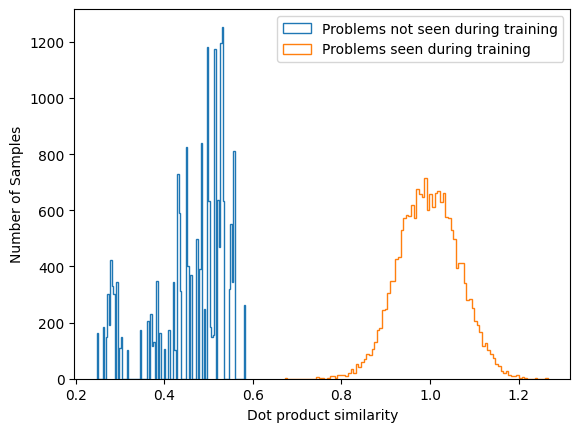

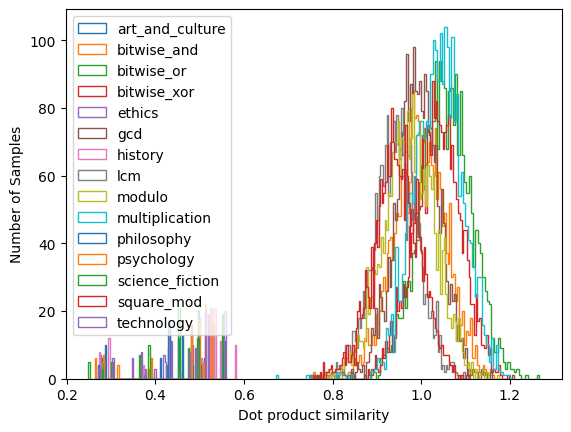

In [9]:
run_id = "8f34shrw"
record_score_per_problem = 3

if record_score_per_problem and test_baseline != 2 and not lora_baseline:
    if record_score_per_problem == 1:
        file_path = f"{curr_dir}/outputs/score_per_problem_training_{run_id}.txt"
    if record_score_per_problem == 2:
        file_path = f"{curr_dir}/outputs/score_per_problem_testing_{run_id}.txt"
    if record_score_per_problem == 3:
        file_path = f"{curr_dir}/outputs/score_per_problem_training_and_testing_{run_id}.txt"

df = pd.read_csv(file_path)

df['training_item'] = [i for i in range(len(df) // len(generator.model.SE.possible_problems)) 
                         for j in range(len(generator.model.SE.possible_problems))]

bins=100

train_problem_scores = df[df.actual_problem_type.isin(generator.model.training_problems)].pivot_table(
    index="training_item", values="score", aggfunc=np.max)
test_problem_scores = df[~df.actual_problem_type.isin(generator.model.training_problems)].pivot_table(
    index="training_item", values="score", aggfunc=np.max)

min_dataset_size = max(len(train_problem_scores), len(test_problem_scores)) * 1

plt.hist(test_problem_scores.sample(min_dataset_size, replace=True).score, bins=bins, histtype="step")
plt.hist(train_problem_scores.sample(min_dataset_size, replace=True).score, bins=bins, histtype="step")
plt.xlabel("Dot product similarity")
plt.ylabel("Number of Samples")
plt.legend([ "Problems not seen during training", "Problems seen during training"])
plt.show()

leg = []
for pt in sorted(set(df.actual_problem_type)):
    plt.hist(df[df.actual_problem_type.isin([pt])].  pivot_table(
        index="training_item", values="score", aggfunc=np.max).score, bins=bins, histtype="step")
    leg += [pt]
plt.xlabel("Dot product similarity")
plt.ylabel("Number of Samples")
plt.legend(leg)
plt.show()

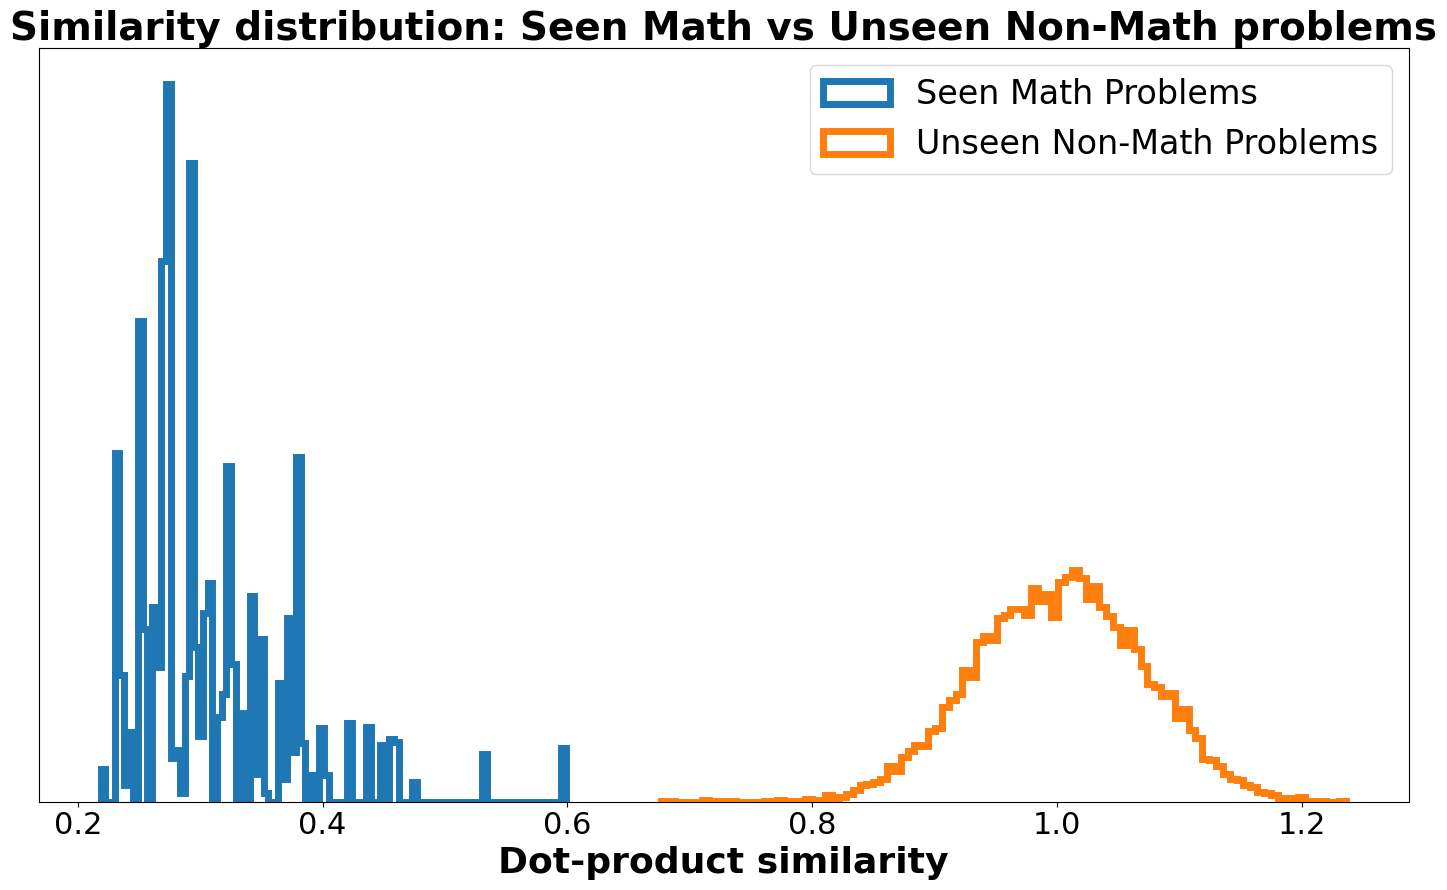

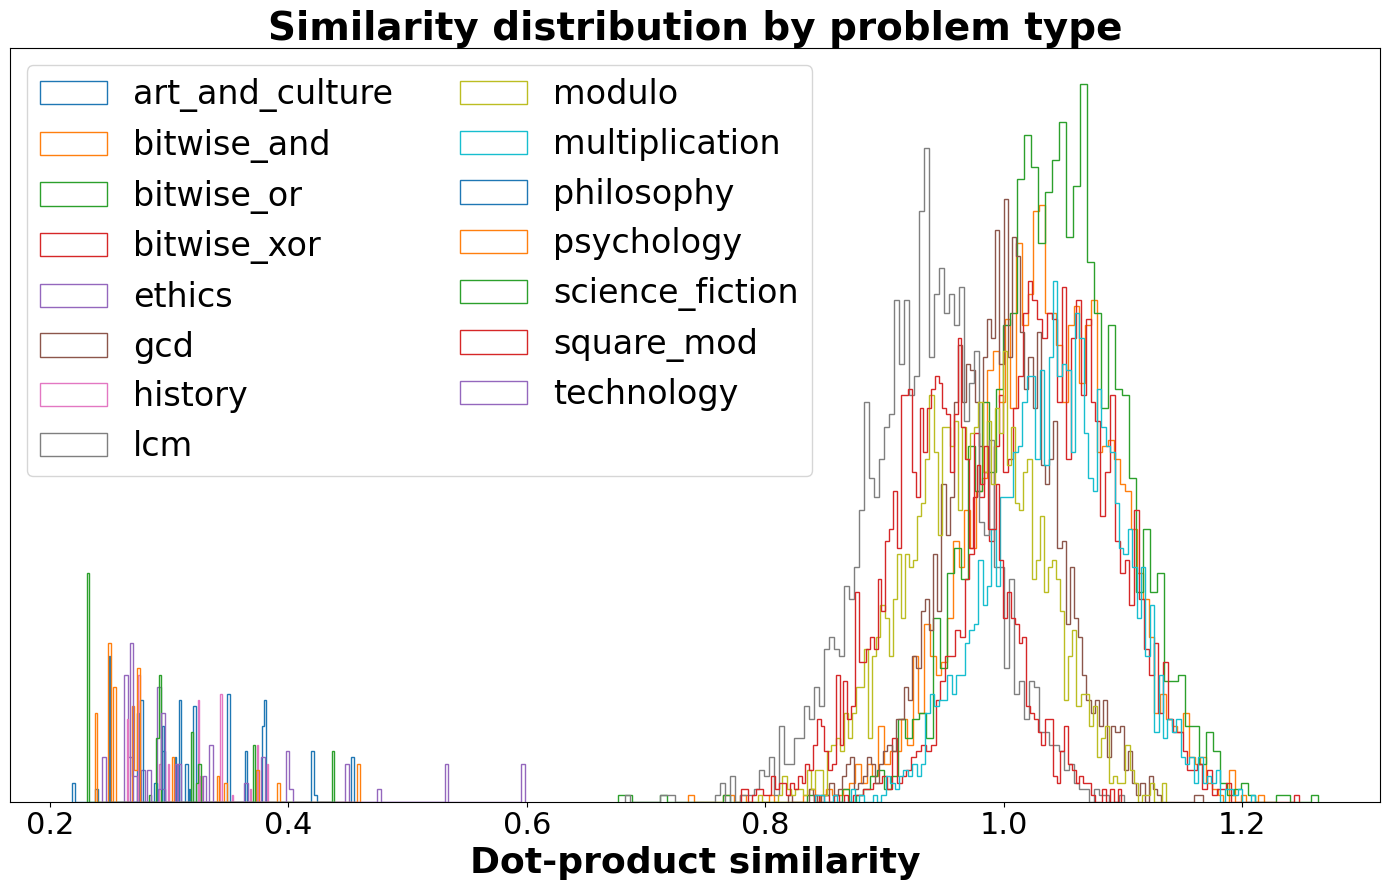

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── GLOBAL STYLE ────────────────────────────────────────────────────────────
mpl.rcParams.update({
    "figure.figsize"  : (14, 9),   # big canvas
    "axes.titlesize"  : 28,
    "axes.titleweight"  : "bold",
    "axes.labelsize"  : 26,
    "axes.labelweight": "bold",
    "xtick.labelsize" : 22,
    "ytick.labelsize" : 22,
    "legend.fontsize" : 24,
    "legend.frameon"  : True,
    "lines.linewidth" : 2.5,
})

# ── READ DATA ───────────────────────────────────────────────────────────────
run_id = "q0zyz3m3"
record_score_per_problem = 3

if record_score_per_problem and test_baseline != 2 and not lora_baseline:
    if record_score_per_problem == 1:
        file_path = f"{curr_dir}/outputs/score_per_problem_training_{run_id}.txt"
    elif record_score_per_problem == 2:
        file_path = f"{curr_dir}/outputs/score_per_problem_testing_{run_id}.txt"
    else:                                       # record_score_per_problem == 3
        file_path = f"{curr_dir}/outputs/score_per_problem_training_and_testing_{run_id}.txt"

df = pd.read_csv(file_path)

# add a running index for each training item so we can pivot by it
items_per_epoch = len(generator.model.SE.possible_problems)
df["training_item"] = np.repeat(np.arange(len(df) // items_per_epoch), items_per_epoch)

# ── TRAIN vs TEST HISTOGRAM ─────────────────────────────────────────────────
bins = 100
train_scores = (
    df[df.actual_problem_type.isin(generator.model.training_problems)]
    .pivot_table(index="training_item", values="score", aggfunc=np.max)
)
test_scores = (
    df[~df.actual_problem_type.isin(generator.model.training_problems)]
    .pivot_table(index="training_item", values="score", aggfunc=np.max)
)

# resample so both series have equal length
min_len = max(len(train_scores), len(test_scores))
train_sample = train_scores.sample(min_len, replace=True).score
test_sample  = test_scores.sample(min_len,  replace=True).score

plt.figure()
plt.hist(test_sample,  bins=bins, linewidth=5, histtype="step", label="Seen Math Problems")
plt.hist(train_sample, bins=bins, linewidth=5, histtype="step", label="Unseen Non-Math Problems")
plt.xlabel("Dot-product similarity")
#plt.ylabel("Number of samples")
plt.yticks([])
plt.title("Similarity distribution: Seen Math vs Unseen Non-Math problems")
plt.legend()
plt.tight_layout()
plt.show()

# ── PER-PROBLEM HISTOGRAMS ─────────────────────────────────────────────────
plt.figure()
legend_labels = []
for pt in sorted(df.actual_problem_type.unique()):
    pt_scores = (
        df[df.actual_problem_type == pt]
        .pivot_table(index="training_item", values="score", aggfunc=np.max)
        .score
    )
    plt.hist(pt_scores, bins=bins, histtype="step")
    legend_labels.append(pt)

plt.xlabel("Dot-product similarity")
#plt.ylabel("Number of samples")
plt.yticks([])
plt.title("Similarity distribution by problem type")
plt.legend(legend_labels, ncol=2)   # two-column legend so it stays compact
plt.tight_layout()
plt.show()


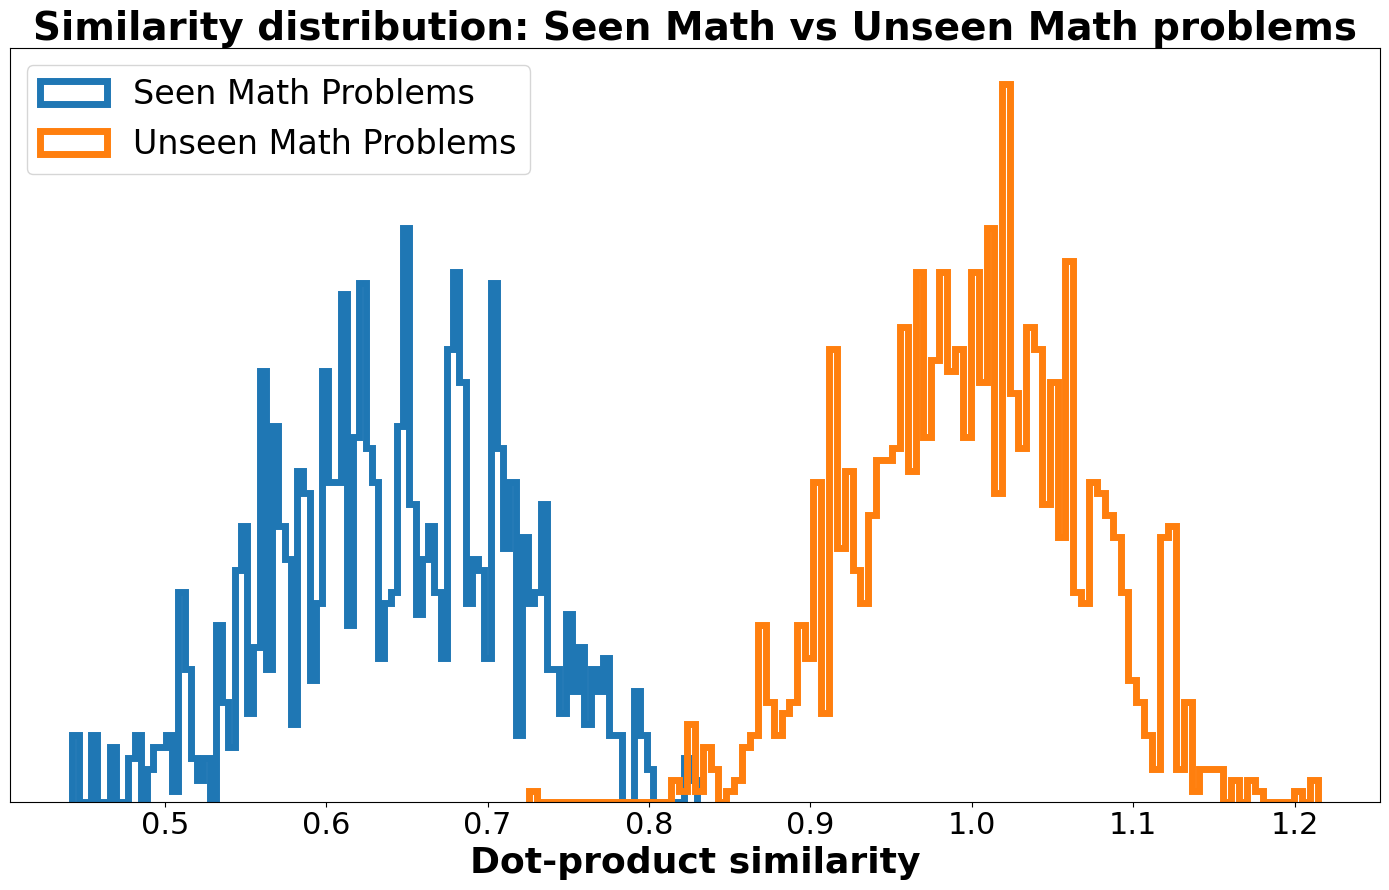

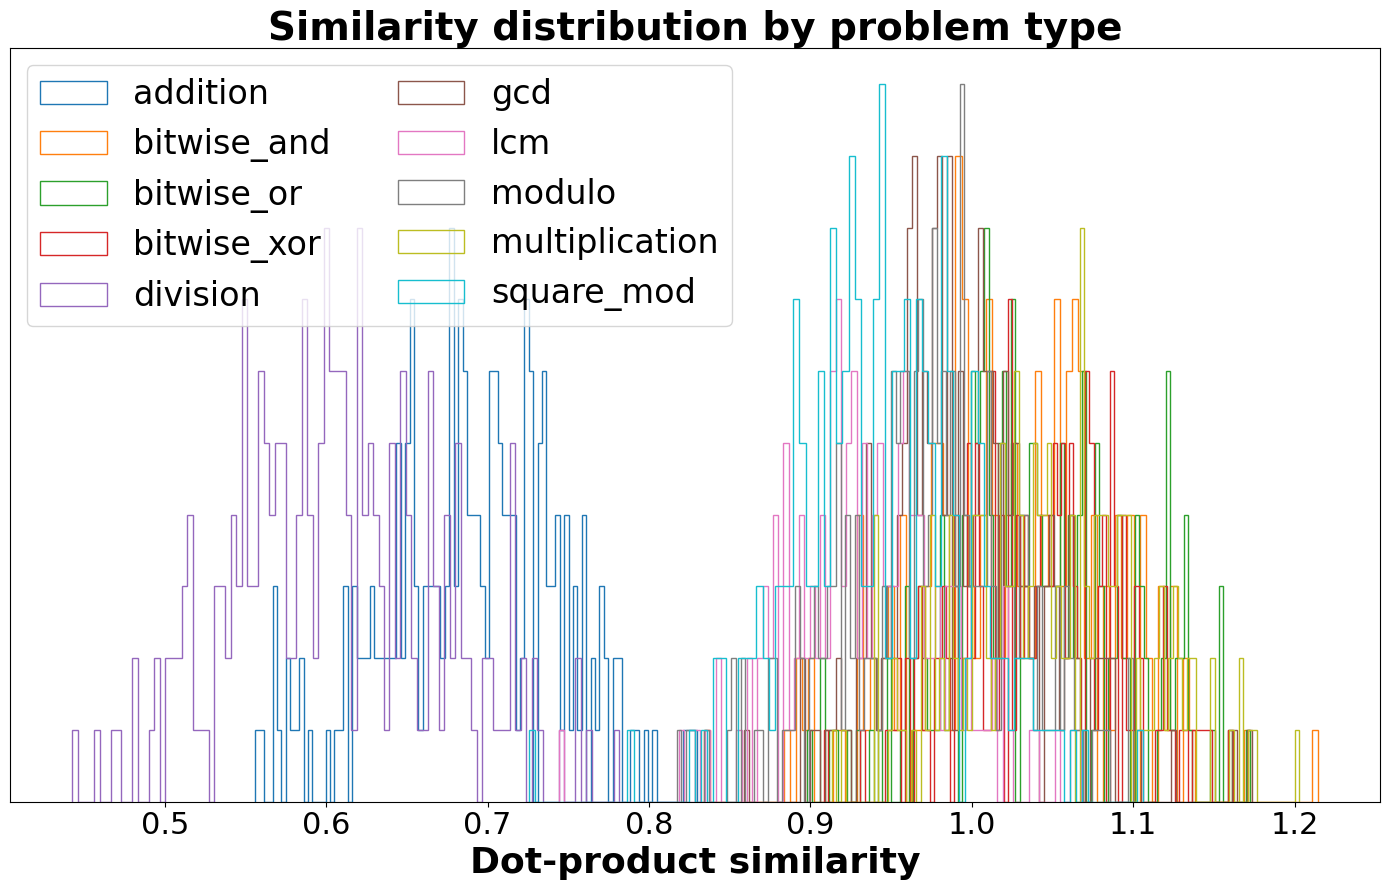

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# # ── GLOBAL STYLE ────────────────────────────────────────────────────────────
# mpl.rcParams.update({
#     "figure.figsize"  : (14, 9),   # big canvas
#     "axes.titlesize"  : 28,
#     "axes.titleweight"  : "bold",
#     "axes.labelsize"  : 26,
#     "axes.labelweight": "bold",
#     "xtick.labelsize" : 22,
#     "ytick.labelsize" : 22,
#     "legend.fontsize" : 24,
#     "legend.frameon"  : True,
#     "lines.linewidth" : 2.5,
# })

# ── READ DATA ───────────────────────────────────────────────────────────────
run_id = "bnzd6vw8"
record_score_per_problem = 2

if record_score_per_problem and test_baseline != 2 and not lora_baseline:
    if record_score_per_problem == 1:
        file_path = f"{curr_dir}/outputs/score_per_problem_training_{run_id}.txt"
    elif record_score_per_problem == 2:
        file_path = f"{curr_dir}/outputs/score_per_problem_testing_{run_id}.txt"
    else:                                       # record_score_per_problem == 3
        file_path = f"{curr_dir}/outputs/score_per_problem_training_and_testing_{run_id}.txt"

df = pd.read_csv(file_path)

# add a running index for each training item so we can pivot by it
items_per_epoch = len(generator.model.SE.possible_problems)
df["training_item"] = np.repeat(np.arange(len(df) // items_per_epoch), items_per_epoch)

# ── TRAIN vs TEST HISTOGRAM ─────────────────────────────────────────────────
bins = 100
train_scores = (
    df[df.actual_problem_type.isin(generator.model.training_problems)]
    .pivot_table(index="training_item", values="score", aggfunc=np.max)
)
test_scores = (
    df[~df.actual_problem_type.isin(generator.model.training_problems)]
    .pivot_table(index="training_item", values="score", aggfunc=np.max)
)

# resample so both series have equal length
min_len = max(len(train_scores), len(test_scores))
train_sample = train_scores.sample(min_len, replace=True).score
test_sample  = test_scores.sample(min_len,  replace=True).score

plt.figure()
plt.hist(test_sample,  bins=bins, linewidth=5, histtype="step", label="Seen Math Problems")
plt.hist(train_sample, bins=bins, linewidth=5, histtype="step", label="Unseen Math Problems")
plt.xlabel("Dot-product similarity")
#plt.ylabel("Number of samples")
plt.yticks([])
plt.title("Similarity distribution: Seen Math vs Unseen Math problems")
plt.legend()
plt.tight_layout()
plt.show()

# ── PER-PROBLEM HISTOGRAMS ─────────────────────────────────────────────────
plt.figure()
legend_labels = []
for pt in sorted(df.actual_problem_type.unique()):
    pt_scores = (
        df[df.actual_problem_type == pt]
        .pivot_table(index="training_item", values="score", aggfunc=np.max)
        .score
    )
    plt.hist(pt_scores, bins=bins, histtype="step")
    legend_labels.append(pt)

plt.xlabel("Dot-product similarity")
#plt.ylabel("Number of samples")
plt.yticks([])
plt.title("Similarity distribution by problem type")
plt.legend(legend_labels, ncol=2)   # two-column legend so it stays compact
plt.tight_layout()
plt.show()


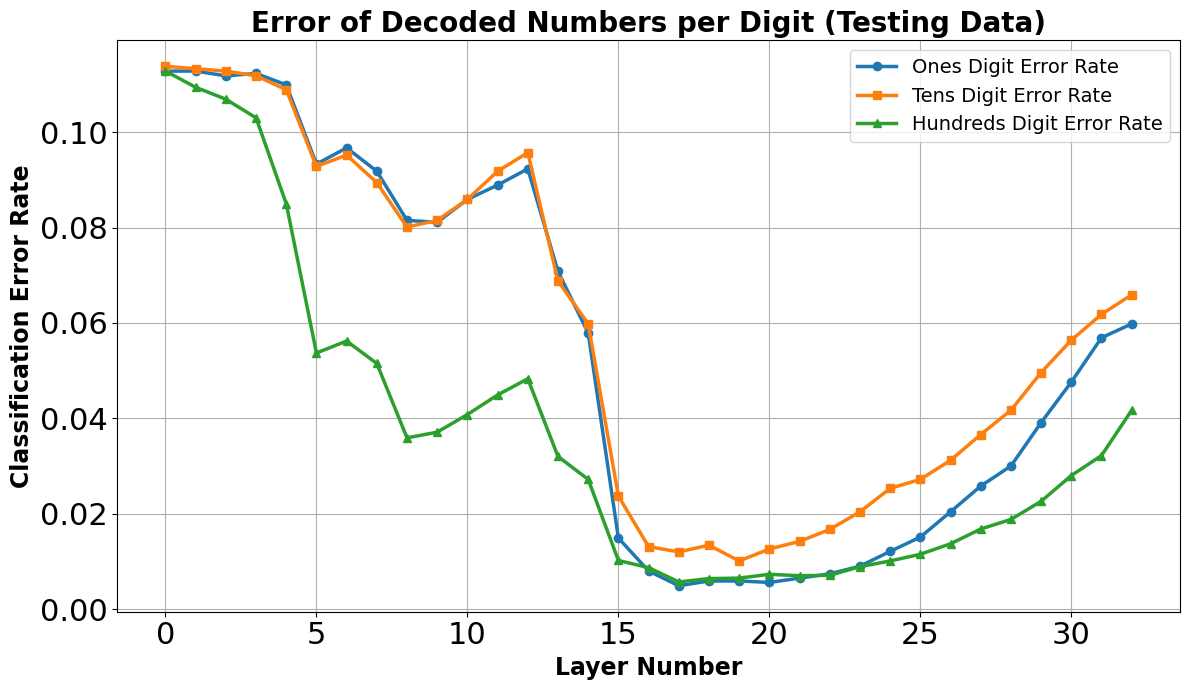

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Paste the error-per-digit values for each layer as rows:
per_digit_errors = np.array([
    [0.1128, 0.1138, 0.1128],
    [0.1128, 0.1133, 0.1094],
    [0.1118, 0.1128, 0.1069],
    [0.1123, 0.1118, 0.1030],
    [0.1099, 0.1089, 0.0850],
    [0.0933, 0.0928, 0.0537],
    [0.0967, 0.0952, 0.0562],
    [0.0918, 0.0894, 0.0515],
    [0.0815, 0.0801, 0.0359],
    [0.0811, 0.0815, 0.0371],
    [0.0859, 0.0859, 0.0408],
    [0.0889, 0.0918, 0.0449],
    [0.0923, 0.0957, 0.0483],
    [0.0708, 0.0688, 0.0320],
    [0.0579, 0.0598, 0.0272],
    [0.0149, 0.0237, 0.0102],
    [0.0080, 0.0131, 0.0087],
    [0.0049, 0.0120, 0.0057],
    [0.0059, 0.0134, 0.0064],
    [0.0059, 0.0101, 0.0065],
    [0.0056, 0.0126, 0.0073],
    [0.0065, 0.0142, 0.0070],
    [0.0074, 0.0167, 0.0071],
    [0.0090, 0.0204, 0.0089],
    [0.0121, 0.0253, 0.0101],
    [0.0151, 0.0272, 0.0115],
    [0.0204, 0.0312, 0.0137],
    [0.0258, 0.0366, 0.0168],
    [0.0300, 0.0417, 0.0188],
    [0.0391, 0.0496, 0.0226],
    [0.0476, 0.0564, 0.0280],
    [0.0569, 0.0618, 0.0322],
    [0.0598, 0.0659, 0.0417]
])

layer_numbers = np.arange(per_digit_errors.shape[0])
labels = ['Ones Digit Error Rate', 'Tens Digit Error Rate', 'Hundreds Digit Error Rate']
markers = ["o", "s", "^"]

plt.figure(figsize=(12,7))
for n, digit in enumerate(per_digit_errors.T):
    plt.plot(layer_numbers, digit, label=labels[n], marker=markers[n])

plt.title("Error of Decoded Numbers per Digit (Testing Data)", fontsize=20)
plt.xlabel('Layer Number', fontsize=17)
plt.ylabel('Classification Error Rate', fontsize=17)
plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
print("Shape:", np.shape(err_matrix))
print("Type:", type(err_matrix), "First few:", err_matrix[:10])


Shape: ()


IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed